# Universidad de Buenos Aires
# Aprendizaje Profundo - TP1
# Cohorte 21 - 4to bimestre 2025


Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23hs del jueves 2 de octubre (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE AL 60% DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/xoqxtBoFYok3542TA)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP1-Co21.ipynb**
- Los códigos deben poder ejecutarse.
- IMPORTANTE: Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **PREGUNTA 1**

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola neurona:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = \tanh(z) = \tanh(w x + b)
$$

\\

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

\\

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

\\

Si bien es cierto, en estos experimentos estamos comparando optimizadores (GD vs Adam), y no entrenando un modelo como tal, de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores. Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`.

\\

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.


### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()` para cada learning rate.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época

\\

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar Pytorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

### 1b) Implementación de Adam (1 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD para cada diferente learning rate.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch (batch size a elección de ustedes).

\\

Al igual que para GD, el optimizador Adam también se debe implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar Pytorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador.

### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico.

# **RESPUESTA 1**

## Imports y creación de dataset **sintético**

***Dataset sintético***

En esta sección se genera un dataset sintético de la siguiente manera:

- $X$: se utiliza la función `np.linspace` entre los valores $-3$ y $3$, con $100$ elementos.
- $y$: se sigue la siguiente fórmula:

$$
f(x) = \begin{cases}
    \text{sen(0.7 * x) + random } & \text{X < 0}\\
    \text{cos(0.66 * x) + random} & \text{X >= 0}
\end{cases}
$$

Donde $random$ corresponde a un valor aleatoria generado a partir de la función `np.random.rand`.

***Weights and biases***

Por último, se crean los *weights* y *biases* que se utilizarán en los distintos experimentos del *Punto 1* (en función de los *Learning Rates*), a fin de que sean los mismos para facilitar su comparación.

Los valores generados aleatoriamente son:

| Experimento | Weight | Bias |
| --- | --- | --- |
| Learning Rate $0.1$ | $0.29442435$ | $0.00406196$ |
| Learning Rate $0.01$ | $-0.465003$ | $-1.05275124$ |
| Learning Rate $0.001$ | $-0.30674614$ | $0.18272894$ |

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
RANDOM_STATE = 649739
CANT_ELEMENTOS = 100
CANT_EPOCHS = 100
learning_rates = [0.1, 0.01, 0.001]
batch_size = 25

In [ ]:
N_SIMETRICO = 3

In [ ]:
np.random.RandomState(RANDOM_STATE)

RandomState(MT19937) at 0x7B07F5F60240

In [ ]:
X = np.linspace(-N_SIMETRICO, N_SIMETRICO, CANT_ELEMENTOS)
y_a = np.sin(0.7 * X[X < 0])
y_b = np.cos(0.66 * X[X >= 0])
y = np.concatenate((y_a, y_b)) + np.random.rand(CANT_ELEMENTOS)

In [ ]:
# Diccionario en donde se guardan los weights y biases para utilizar
# en cada learning rate. De esta forma se asegura que tanto en Gradient Descent
# como en las distintos ADAMS se usen los mismos valores
weight_and_biases_for_lr = {}

In [ ]:
for lr in learning_rates:
  w_ini = np.random.randn(1)
  b_ini = np.random.randn(1)
  weight_and_biases_for_lr[str(lr)] = [w_ini, b_ini]

In [ ]:
weight_and_biases_for_lr

{'0.1': [array([0.29442435]), array([0.00406196])],
 '0.01': [array([-0.465003]), array([-1.05275124])],
 '0.001': [array([-0.30674614]), array([0.18272894])]}

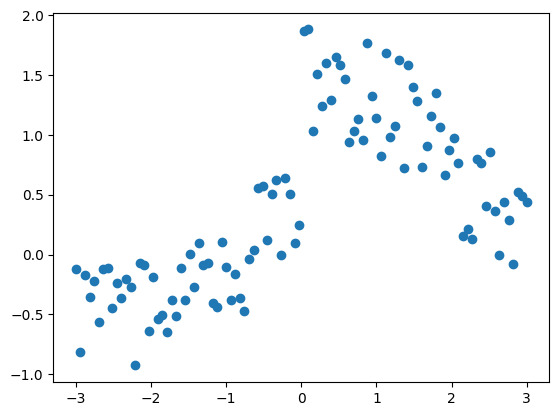

In [ ]:
plt.scatter(X, y)

## 1a) Implementación del Gradiente Descendente

En esta sección se implementará el algoritmo de `Gradiente Descendente` de manera manual, y se realizarán pruebas con distintos *learning rates* para analizar la trayectoria de aprendizaje, evaluando su eficiencia.

Se utilizará la función de activación de `tangente hiperbólica`:

***Función de activación***
$$
\hat{y} = \tanh(z) = \tanh(w x + b)
$$

***Función de costo***

Se utilizará la función de costo de `Error Cuadrático Medio (MSE)`:

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

la cual, en términos de $w$ (pesos) y $b$ (bias) se expresa como:

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

***Descripción del algoritmo***

El algoritmo de `Gradiente Descendente` consta de:

- Una etapa de `forward pass`, en donde a partir de los datos ($X$), pesos ($W$) y bias ($b$) se calcula una aproximación de $y$ (o $\hat{y}$) utilizando la función de activación ($tanh$ en nuestro caso).
- Cálculo del error, a partir de $y$, $\hat{y}$ y la función de costo ($MSE$).
- Un paso de `backward pass`, en donde el algoritmo realiza ajustes a los pesos $W$ y bias $b$ en función de como estos *"afectan"* a la función de error, lo cual se hace a partir de las derivadas parciales de cada uno de estos hiperparámetros en función de la función de costo.

***Cálculo de Derivadas parciales***

Respecto de $w$ (pesos o *weights*):
$$
\frac{\partial J}{\partial w} = \frac{2}{m} \sum_{i=1}^{m}(\tanh(w x_i + b) - y_i ) * (1-(\tanh(w x_i + b))^{2}) * x_i
$$
$$
\frac{\partial J}{\partial w} = \frac{2}{m} \sum_{i=1}^{m}(\hat{y}_i - y_i ) * (1-(\hat{y}_i )^{2}) * x_i
$$

Respecto de $b$ (bias):
$$
\frac{\partial J}{\partial b} = \frac{2}{m} \sum_{i=1}^{m}(\tanh(w x_i + b) - y_i ) * (1-(\tanh(w x_i + b))^{2})
$$
$$
\frac{\partial J}{\partial b} = \frac{2}{m} \sum_{i=1}^{m}(\hat{y}_i - y_i ) * (1-(\hat{y}_i )^{2})
$$

***Implementación del algoritmo***

Ya definidas las derivadas parciales, se implementa el algoritmo de `Gradiente Descendente`:

In [ ]:
def custom_gradient_descent(X, y, learning_rate: float, epochs: int,
                            w_ini: float, b_ini: float, random_state: int):
  np.random.RandomState(random_state)

  cantidad_elementos = X.shape[0]

  # Si es un array de n elementos, lo convertimos en matriz de nx1
  # para facilitar calculos
  if X.shape == (cantidad_elementos, ):
    X = X.reshape(cantidad_elementos, 1)

  cantidad_features = X.shape[1]

  weights = w_ini
  bias = b_ini

  loss = []

  for epoch in range(epochs):
    ##### Forward pass
    z = np.dot(X, weights) + bias
    y_hat = np.tanh(z)

    # Calculamos el error
    mse = np.mean((y_hat - y)**2)
    # Agregamos el error a la lista
    loss.append(mse)

    ##### Backward pass
    # Derivada de función perdida respecto de predicción (y_hat)
    d_mse_d_y_hat = 2 * (y_hat - y) / cantidad_elementos
    # Derivada de predicción (y_hat) respecto de z
    d_y_hat_z = 1.0 - (np.tanh(z))**2
    # Derivada de función de perdida respecto a z
    d_mse_d_z = d_mse_d_y_hat * d_y_hat_z
    # Derivada de función perdida respecto de pesos
    d_mse_d_weights = np.dot(X.T, d_mse_d_z)
    # Derivada de función perdida respecto de bias
    d_mse_d_bias = np.sum(d_mse_d_z)

    # Actualizamos pesos y biases
    weights = weights - learning_rate * d_mse_d_weights
    bias = bias - learning_rate * d_mse_d_bias

  return weights, bias, np.array(loss)


### Gráficos de función de costo en función del epoch

A continuación se grafica la función de costo para el experimento de `Gradient Descent` con learning rate de $0.1$ y $100$ epochs.

En este caso se observa como el algoritmo va aprendiendo, y por lo tanto, reduciendo el error, rápidamente hasta el epoch $20$ aproximandamente.

Luego, el valor de la funciónde péridida decrece lentamente.

En otras palabras, converge rápidamente a un mínimo entre los epochs $0$ y $20$, y en los siguientes queda "atascado" en este mínimo, de ahí a que no haya mejoras.

Text(0, 0.5, 'Loss')

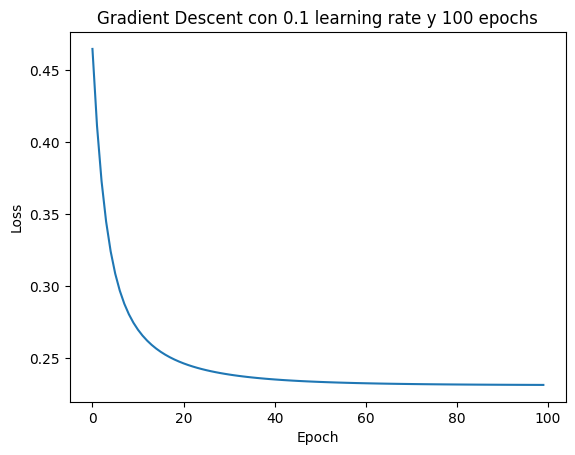

In [ ]:
lr = learning_rates[0]
w_b_ini = weight_and_biases_for_lr[str(lr)]
w_gd_01, b_gd_01, l_gd_01 = custom_gradient_descent(X=X, y=y, learning_rate=lr, epochs=CANT_EPOCHS, w_ini=w_b_ini[0], b_ini=w_b_ini[1],random_state=RANDOM_STATE)
plt.plot([i for i in range(len(l_gd_01))], l_gd_01)
plt.title(f"Gradient Descent con {lr} learning rate y {CANT_EPOCHS} epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

A continuación se grafica la función de costo para el experimento de `Gradient Descent` con learning rate de $0.01$ y $100$ epochs.

En este caso, sucede que el algoritmo reduce el costo lentamente entre los epochs $0$ y $40$/$50$, para luego hacer un salto significativo.

A diferencia del caso de learning rate $0.1$, sucede que el algoritmo no converge rápidamente, sino que lo hace lentamente hasta el epoch $40$/$50$. Además, no parece quedarse "estancado" en un mínimo, sino que sigue explorando otros valores.

Text(0, 0.5, 'Loss')

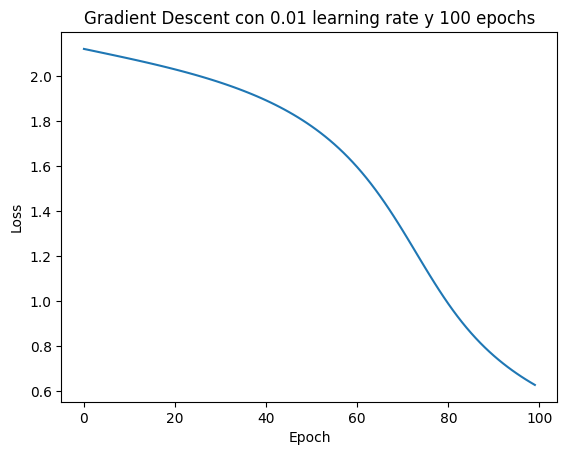

In [ ]:
lr = learning_rates[1]
w_b_ini = weight_and_biases_for_lr[str(lr)]
w_gd_02, b_gd_02, l_gd_02 = custom_gradient_descent(X=X, y=y, learning_rate=lr, epochs=CANT_EPOCHS, w_ini=w_b_ini[0], b_ini=w_b_ini[1],random_state=RANDOM_STATE)
plt.plot([i for i in range(len(l_gd_02))], l_gd_02)
plt.title(f"Gradient Descent con {lr} learning rate y {CANT_EPOCHS} epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

A continuación se grafica la función de costo para el experimento de `Gradient Descent` con learning rate de $0.001$ y $100$ epochs.

Como se puede observar, en este caso el algoritmo aprende lentamente, a modo de que en los $100$ epochs no llega a converger a un mínimo.

Text(0, 0.5, 'Loss')

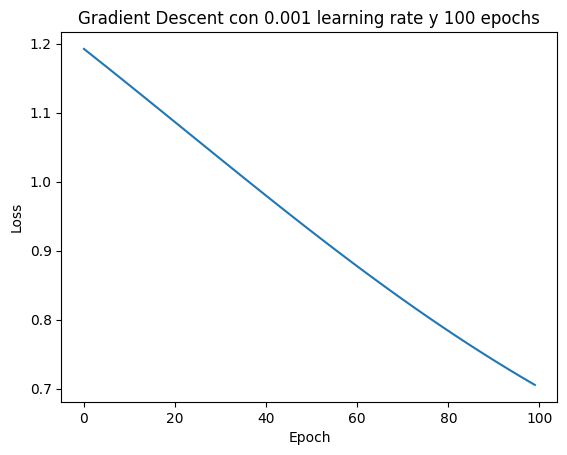

In [ ]:
lr = learning_rates[2]
w_b_ini = weight_and_biases_for_lr[str(lr)]
w_gd_03, b_gd_03, l_gd_03 = custom_gradient_descent(X=X, y=y, learning_rate=lr, epochs=CANT_EPOCHS, w_ini=w_b_ini[0], b_ini=w_b_ini[1],random_state=RANDOM_STATE)
plt.plot([i for i in range(len(l_gd_03))], l_gd_03)
plt.title(f"Gradient Descent con {lr} learning rate y {CANT_EPOCHS} epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

Finalmente, comparamos los gráficos de los tres casos explorados.

- El caso de $0.1$ (en azul) converge rápidamente, quedándose cerca de un mínimo, el cual podría ser local y no global.
- El caso de $0.001$ decrece lentamente, además de que parece requerir muchos más epochs para converger a un mínimo.
- El caso de $0.01$ comienza decreciendo lentamente, para luego hacer un salto significativo respecto al valor de costo. Si bien sigue siendo mayor al del caso de $0.1$, mejora al caso de $0.001$, además de que podría llegar a un mínimo potencialmente global con un mayor valor de epochs.

Text(0, 0.5, 'Loss')

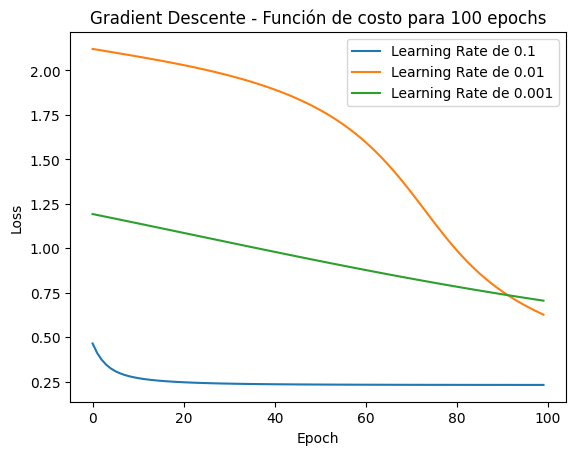

In [ ]:
plt.plot(l_gd_01, label="Learning Rate de 0.1")
plt.plot(l_gd_02, label="Learning Rate de 0.01")
plt.plot(l_gd_03, label="Learning Rate de 0.001")
plt.legend()
plt.title(f"Gradient Descente - Función de costo para 100 epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

## 1b) Implementación de Adam

A continuación se muestra el pseudo-código correspondiente al algoritmo de *Adam* definido en el libro *Deep Learning* de Ian Goodfellow (capítulo 8):

**Require**: Step size $ϵ$ (Suggested default: $0.001$) </br>
**Require**: Exponential decay rates for moment estimates, $ρ_1$ and $ρ_2$ in $[0, 1)$.
(Suggested defaults: $0.9$ and $0.999$ respectively) </br>
**Require**: Small constant $δ$ used for numerical stabilization. (Suggested default: $10^{−8}$) </br>
**Require**: Initial parameters $θ$ </br>
&emsp;Initialize 1st and 2nd moment variables $s = 0$, $r = 0$ </br>
&emsp;Initialize time step $t = 0$ </br>
&emsp;**while** stopping criterion not met **do** </br>
&emsp;&emsp;Sample a minibatch of m examples from the training set {x(1), . . . ,x(m) } with corresponding targets y(i). </br>
&emsp;&emsp;Compute gradient: $g ← \frac{1}{m}∇_{θ}∑_iL(f(x^{(i)}; θ), y^{(i)})$ </br>
&emsp;&emsp;$t ← t + 1$ </br>
&emsp;&emsp;Update biased first moment estimate: $s ← ρ_1 s + (1 − ρ_1 )g$  </br>
&emsp;&emsp;Update biased second moment estimate: $r ← ρ_2r + (1 − ρ_2 )g ⊙ g$  </br>
&emsp;&emsp;Correct bias in first moment: $\hat{s} ← \frac{s}{1-ρ^{t}_{1}}$</br>
&emsp;&emsp;Correct bias in second moment: $\hat{r} ← \frac{r}{1-ρ^{t}_{2}}$</br>
&emsp;&emsp;Compute update: $Δθ = -ϵ \frac{\hat{s}}{\sqrt{\hat{r}} + δ}$
*(operations applied element-wise)*</br>
&emsp;&emsp;Apply update: $θ ← θ + Δθ$ </br>
  **end while**

En nuestros casos de estudio utilizaremos los valores recomendados para los siguientes hiperparámetros:

- $ρ_1$ = $0.9$ => Permite ajustar el bias asociado al *primer momento*.
- $ρ_2$ = $0.999$ => Permite ajustar el bias asociado al *segundo momento*.
- $δ$ = $10^{-8}$ => Evita la división por cero al calcular el $delta$ de $w$ y $b$ (o $Δθ$, según la bibliografía).

Para $w$ y $b$ se usan los valores definidos al comienzo de este ejercicio.

### Adam - full-batch

La diferencia entre full batch y mini batch es el tamaÑo de los batches.

Por ello, en la implementación de `custom_adam_mini_batch` utilizaremos el valor de `batch_size` igual a $0$ para el caso de ***Full Batch***, mientras que para ***Mini Batch*** utilizaremos batches de $25$.

In [ ]:
def custom_adam_mini_batch(X, y, epochs: int, random_state: int,
                           w_ini: float, b_ini: float,
                           learning_rate: float, delta: float = 1e-8,
                           ro_1: float = 0.9, ro_2: float = 0.999,
                           batch_size: int = 0):
  np.random.RandomState(random_state)

  cantidad_elementos = X.shape[0]

  if batch_size == 0:
    batch_size = cantidad_elementos

  # Si es un array de n elementos, lo convertimos en matriz de nx1
  # para facilitar calculos
  if X.shape == (cantidad_elementos, ):
    X = X.reshape(cantidad_elementos, 1)

  cantidad_features = X.shape[1]

  weights = w_ini
  bias = b_ini
  loss = []
  s = 0
  r = 0
  step = 0

  for epoch in range(epochs):
    indices = np.random.permutation(cantidad_elementos)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    epoch_loss = 0.0
    num_batches = 0

    for i in range(0, cantidad_elementos, batch_size):
      X_batch = X_shuffled[i:i + batch_size]
      y_batch = y_shuffled[i:i + batch_size]

      ##### Paso: Forward pass
      z = np.dot(X_batch, weights) + bias
      y_hat = np.tanh(z)

      # Calculamos el error
      mse = np.mean((y_hat - y_batch)**2)

      ##### Paso: Backward pass - Calculo de gradientes
      # Derivada de función perdida respecto de predicción (y_hat)
      d_mse_d_y_hat = 2 * (y_hat - y_batch) / cantidad_elementos
      # Derivada de predicción (y_hat) respecto de z
      d_y_hat_z = 1.0 - (np.tanh(z))**2
      # Derivada de función de perdida respecto a z
      d_mse_d_z = d_mse_d_y_hat * d_y_hat_z
      # Derivada de función perdida respecto de pesos
      d_mse_d_weights = np.dot(X_batch.T, d_mse_d_z)
      # Derivada de función perdida respecto de bias
      d_mse_d_bias = np.sum(d_mse_d_z)

      nabla = np.array([np.sum(d_mse_d_weights), d_mse_d_bias])

      ##### Paso: t ← t + 1
      step = step + 1
      ##### Paso: actualizo momento de primer orden = s←ρ1s+(1−ρ1)g
      s = ro_1*s + (1-ro_1) * nabla
      ##### Paso: actualizo momento de segundo orden = r←ρ2r+(1−ρ2)g⊙g
      r = ro_2*r + (1-ro_2) * nabla * nabla
      ##### Paso: corrección bias en momento de primer orden
      s_hat = s/(1-ro_1**step)
      ##### Paso: corrección bias en momento de segundo orden
      r_hat = r/(1-ro_2**step)
      ##### Paso: actualizo Δθ
      lambda_theta = -learning_rate*s_hat/(np.sqrt(r_hat) + delta)
      ##### Paso: actualizo θ←θ+Δθ
      weights = weights + lambda_theta[0]
      bias = bias + lambda_theta[1]

      epoch_loss += mse
      num_batches += 1

    # Agregamos el error a la lista
    loss.append(epoch_loss/num_batches)

  return weights, bias, np.array(loss)

A continuación se grafica la función de costo en función de los epochs para Adam Full batch, con learning rate de $0.1$ y $100$ epochs.

En esta caso, el algoritmo converge rápidamente entre los epochs $0$ y $15$ (aprox), es decir, llega a un mínimo.

Entre los epochs $15$ y $40$, explora otros valores, es decir, sale del mínimo anterior.

Entre los epochs $40$ y $100$, parece volver a explorar la zona del mínimo explorado entre los epochs $0$ y $15$, es decir, vuelve a "atascarse" en la misma zona.

Text(0, 0.5, 'Loss')

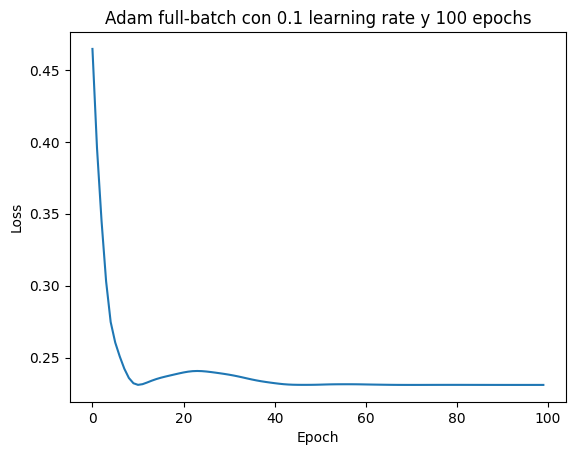

In [ ]:
lr = learning_rates[0]
w_b_ini = weight_and_biases_for_lr[str(lr)]
w_fb_01, b_fb_01, l_fb_01 = custom_adam_mini_batch(X=X, y=y, learning_rate=lr, epochs=CANT_EPOCHS, w_ini=w_b_ini[0], b_ini=w_b_ini[1],random_state=RANDOM_STATE)
plt.plot([i for i in range(len(l_fb_01))], l_fb_01)
plt.title(f"Adam full-batch con {lr} learning rate y {CANT_EPOCHS} epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

A continuación se grafica la función de costo en función de los epochs para Adam Full batch, con learning rate de $0.01$ y $100$ epochs.

El algoritmo converge lentamente entre los epochs $0$ y $20$, para hacer un salto "significativo" en los epochs posteriores.

Text(0, 0.5, 'Loss')

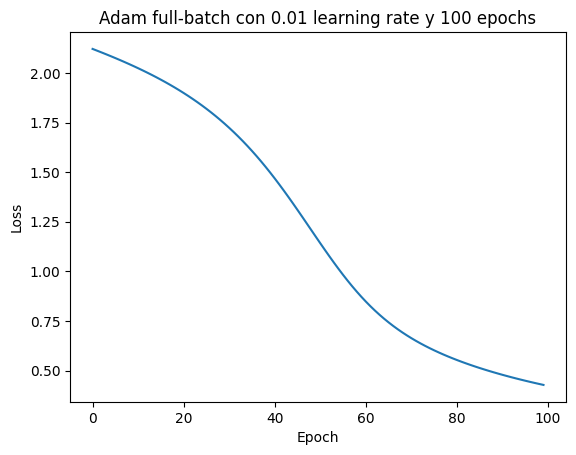

In [ ]:
lr = learning_rates[1]
w_b_ini = weight_and_biases_for_lr[str(lr)]
w_fb_02, b_fb_02, l_fb_02 = custom_adam_mini_batch(X=X, y=y, learning_rate=lr, epochs=CANT_EPOCHS, w_ini=w_b_ini[0], b_ini=w_b_ini[1],random_state=RANDOM_STATE)
plt.plot([i for i in range(len(l_fb_02))], l_fb_02)
plt.title(f"Adam full-batch con {lr} learning rate y {CANT_EPOCHS} epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

A continuación se grafica la función de costo en función de los epochs para Adam Full batch, con learning rate de $0.001$ y $100$ epochs.

Como se puede observar, en este caso el algoritmo aprende lentamente, a modo de que en los $100$ epochs no llega a converger a un mínimo.

Text(0, 0.5, 'Loss')

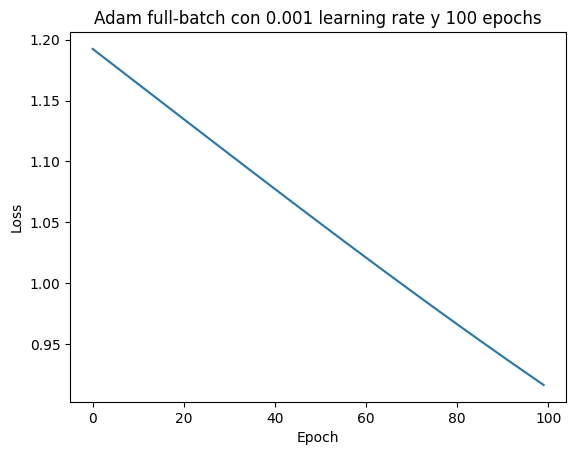

In [ ]:
lr = learning_rates[2]
w_b_ini = weight_and_biases_for_lr[str(lr)]
w_fb_03, b_fb_03, l_fb_03 = custom_adam_mini_batch(X=X, y=y, learning_rate=lr, epochs=CANT_EPOCHS, w_ini=w_b_ini[0], b_ini=w_b_ini[1],random_state=RANDOM_STATE)
plt.plot([i for i in range(len(l_fb_03))], l_fb_03)
plt.title(f"Adam full-batch con {lr} learning rate y {CANT_EPOCHS} epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

Se comparan a continuación las curvas correspondientes a la función costo vs número de epoch para el algoritmo Adam full batch, con $100$ epochs y learning rates de $0.1$, $0.01$ y $0.001$.

Se puede observar que el caso de learning rate de $0.1$ converge rápidamente en los primeros epochs a un mínimo.

Para el caso de learning rate $0.001$ el algoritmo no converge, sino que aprende lentamente.

Mientras que el learning rate de $0.01$ comienza aprendiendo lentamente, luego hace un salto significativo, hasta acercarse a un valor mínimo que disminuye el costo de manera que se "acerca" al costo logrado en el caso de learning rate de $0.1$.

Text(0, 0.5, 'Loss')

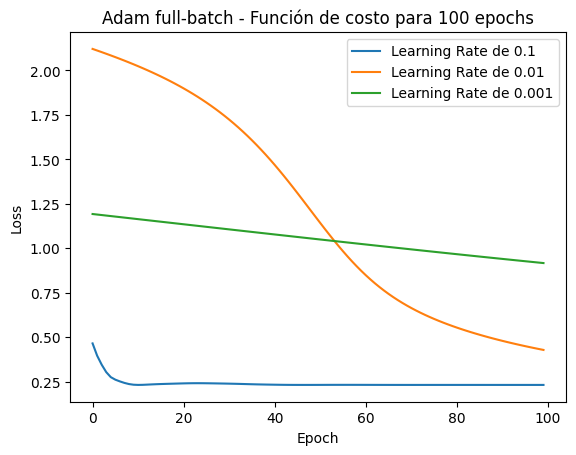

In [ ]:
plt.plot(l_fb_01, label="Learning Rate de 0.1")
plt.plot(l_fb_02, label="Learning Rate de 0.01")
plt.plot(l_fb_03, label="Learning Rate de 0.001")
plt.legend()
plt.title(f"Adam full-batch - Función de costo para 100 epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

### Adam - mini-batch

El siguiente gráfico corresponde a la función de costo vs número de epoch para el algoritmo Adam mini batch con $100$ epochs, learning rate de $0.1$ y batch size de $25$.

En este caso el algoritmo converge rápidamente en los primeros epochs, llegando a un valor mínimo. Si bien explora otros valores distintos al mínimo alcanzado en los siguientes epochs, el algoritmo no se "aleja" de esa zona.

Text(0, 0.5, 'Loss')

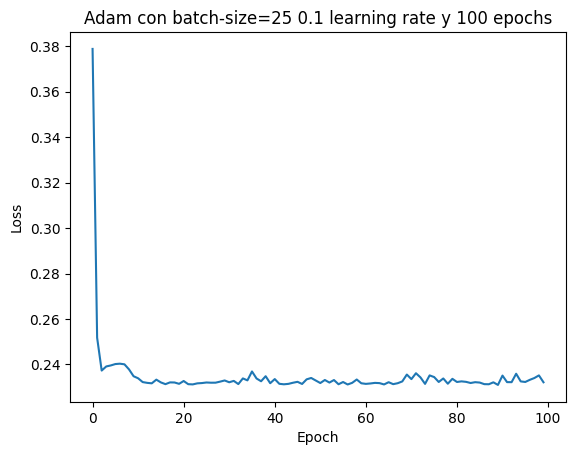

In [ ]:
lr = learning_rates[0]
w_b_ini = weight_and_biases_for_lr[str(lr)]
w_mb_01, b_mb_01, l_mb_01 = custom_adam_mini_batch(X=X, y=y, learning_rate=lr, epochs=CANT_EPOCHS, w_ini=w_b_ini[0], b_ini=w_b_ini[1],random_state=RANDOM_STATE, batch_size=batch_size)
plt.plot([i for i in range(len(l_mb_01))], l_mb_01)
plt.title(f"Adam con batch-size={batch_size} {lr} learning rate y {CANT_EPOCHS} epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

El siguiente gráfico corresponde a la función de costo vs número de epoch para el algoritmo Adam mini batch con $100$ epochs, learning rate de $0.01$ y batch size de $25$.

El algoritmo comienza aprendiendo lentamente, hace un salto significativo entre los epochs $10$ (aprox) y $25$ (aprox), para luego converger a un mínimo cerca del epoch $40$.


Text(0, 0.5, 'Loss')

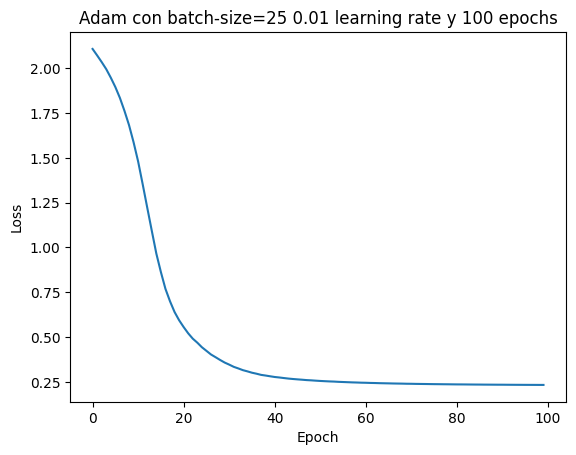

In [ ]:
lr = learning_rates[1]
w_b_ini = weight_and_biases_for_lr[str(lr)]
w_mb_02, b_mb_02, l_mb_02 = custom_adam_mini_batch(X=X, y=y, learning_rate=lr, epochs=CANT_EPOCHS, w_ini=w_b_ini[0], b_ini=w_b_ini[1],random_state=RANDOM_STATE, batch_size=batch_size)
plt.plot([i for i in range(len(l_mb_02))], l_mb_02)
plt.title(f"Adam con batch-size={batch_size} {lr} learning rate y {CANT_EPOCHS} epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

A continuación se grafica la función de costo en función de los epochs para Adam Mini batch, con learning rate de $0.001$ y $100$ epochs.

Como se puede observar, en este caso el algoritmo aprende lentamente, a modo de que en los $100$ epochs no llega a converger a un mínimo.

Text(0, 0.5, 'Loss')

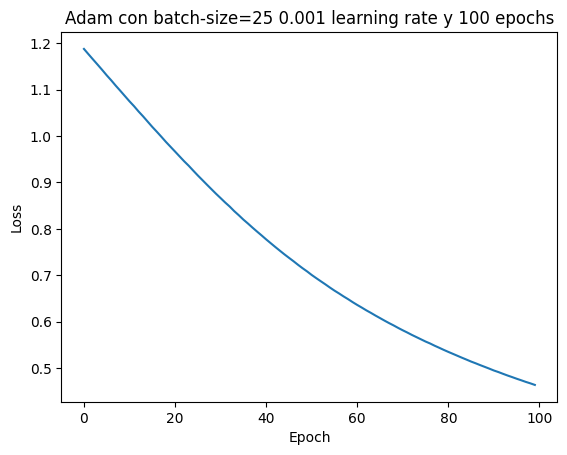

In [ ]:
lr = learning_rates[2]
w_b_ini = weight_and_biases_for_lr[str(lr)]
w_mb_03, b_mb_03, l_mb_03 = custom_adam_mini_batch(X=X, y=y, learning_rate=lr, epochs=CANT_EPOCHS, w_ini=w_b_ini[0], b_ini=w_b_ini[1],random_state=RANDOM_STATE, batch_size=batch_size)
plt.plot([i for i in range(len(l_mb_03))], l_mb_03)
plt.title(f"Adam con batch-size={batch_size} {lr} learning rate y {CANT_EPOCHS} epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

A continuación se grafican las funciones de costos respecto a los epochs para el algoritmo Adam Mini Batch, utilizando $100$ epochs, $25$ como batch size, y learning rates de $0.1$, $0.01$ y $0.001$.

Text(0, 0.5, 'Loss')

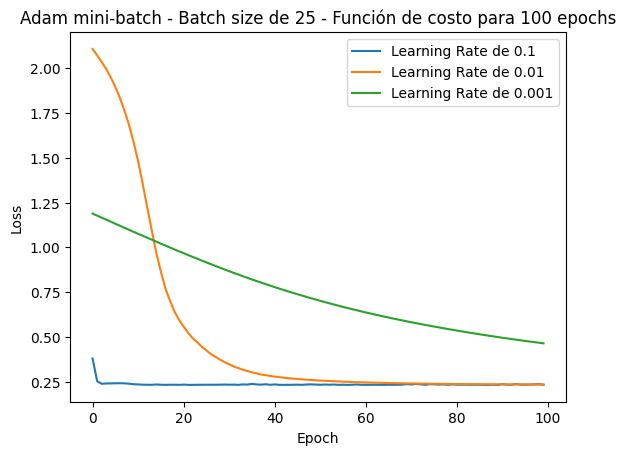

In [ ]:
plt.plot(l_mb_01, label="Learning Rate de 0.1")
plt.plot(l_mb_02, label="Learning Rate de 0.01")
plt.plot(l_mb_03, label="Learning Rate de 0.001")
plt.legend()
plt.title(f"Adam mini-batch - Batch size de 25 - Función de costo para 100 epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

## 1c) Comparativa de optimizadores

En esta sección se comparan los tres algoritmos estudiados: `Gradient Descent`, `Adam Full Batch` y `Adam Mini-Batch`.



Los hiperparámetros utilizados para cada experimento son:

***Todo los experimentos***

- Cantidad de *epoch* = $100$

| Experimento | Weight | Bias |
| --- | --- | --- |
| Learning Rate $0.1$ | $0.29442435$ | $0.00406196$ |
| Learning Rate $0.01$ | $-0.465003$ | $-1.05275124$ |
| Learning Rate $0.001$ | $-0.30674614$ | $0.18272894$ |

***Adam Full Batch y Mini Batch***

- $ρ_1$ = $0.9$
- $ρ_2$ = $0.999$
- $δ$ = $10^{-8}$

***Adam Mini Batch***
- Batch size = $25$

Para el caso correspondiente a ***learning rate*** de $0.1$ se observa que:

- ***Adam Mini Batch*** es el que converge más rápido de los tres, seguido por *Adam Full batch* y por *Gradient Descent*.
- Tanto *Adam Mini Batch* como *Adam Full Batch* presentan oscilaciones, es decir, llegan a un mínimo, pero siguen explorando otros valores, cosa que no sucede con el algoritmo de *Gradient Descent*, ya que NO explora otros valores.

Text(0, 0.5, 'Loss')

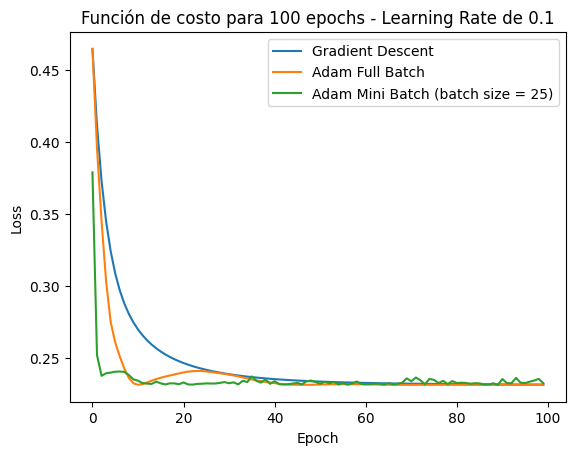

In [ ]:
plt.plot(l_gd_01, label="Gradient Descent")
plt.plot(l_fb_01, label="Adam Full Batch")
plt.plot(l_mb_01, label="Adam Mini Batch (batch size = 25)")
plt.legend()
plt.title(f"Función de costo para 100 epochs - Learning Rate de 0.1")
plt.xlabel("Epoch")
plt.ylabel("Loss")

Para el caso correspondiente a ***learning rate*** de $0.01$ se observa que:

- ***Adam Mini Batch*** es el que converge más rápido de los tres, seguido por *Adam Full batch* y por *Gradient Descent*.
- En este caso NO hay oscilaciones en los $100$ epochs, tal como sucedió para el caso de estudio de ***learning rate*** de $0.1$.

Text(0, 0.5, 'Loss')

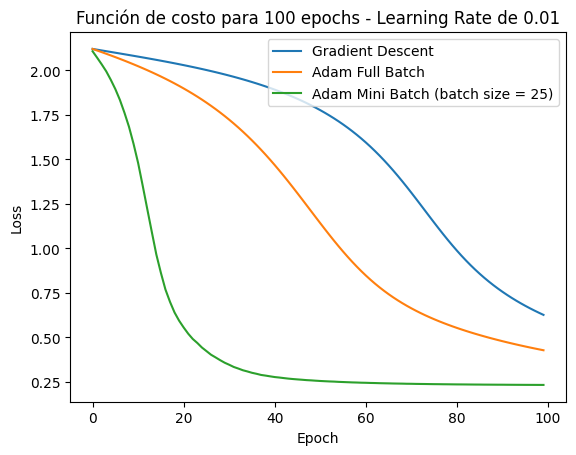

In [ ]:
plt.plot(l_gd_02, label="Gradient Descent")
plt.plot(l_fb_02, label="Adam Full Batch")
plt.plot(l_mb_02, label="Adam Mini Batch (batch size = 25)")
plt.legend()
plt.title(f"Función de costo para 100 epochs - Learning Rate de 0.01")
plt.xlabel("Epoch")
plt.ylabel("Loss")

Para el caso correspondiente a ***learning rate*** de $0.001$ se observa que:

- Si bien los tres algoritmos convergen lentamente, ***Adam Mini Batch*** es el que converge más rápido de los tres, seguido por *Gradient Descent* y por *Adam Full batch*.
- En ninguno de los casos podemos asegurar que se llegue a un mínimo, pero de haber más epochs, el que probablemente llegue a converger primero es el algoritmo de ***Adam Mini Batch***.

Text(0, 0.5, 'Loss')

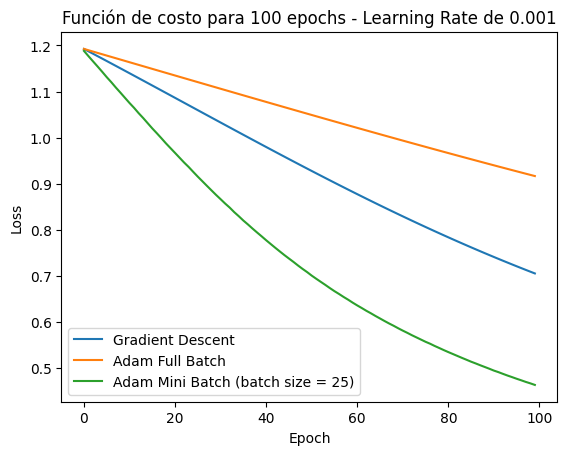

In [ ]:
plt.plot(l_gd_03, label="Gradient Descent")
plt.plot(l_fb_03, label="Adam Full Batch")
plt.plot(l_mb_03, label="Adam Mini Batch (batch size = 25)")
plt.legend()
plt.title(f"Función de costo para 100 epochs - Learning Rate de 0.001")
plt.xlabel("Epoch")
plt.ylabel("Loss")

***Conclusiones***

En función de los distintos experimentos realizados podemos decir que el algoritmo de ***Adam Mini Batch*** se caracteriza por converger de manera mucho más rápida que los algoritmos de ***Adam Full Batch*** y ***Gradient Descent***, al estudiarlos en $100$ epochs, con learning rates de $0.1$, $0.01$ y $0.001$, con los mismos hiperparámetros de $w$ y $b$ para los tres algoritmos (y $ρ_1$, $ρ_2$ y $δ$ para ambos algoritmos de Adam).

En general, ambos algoritmos de *Adam* convergen más rápido que el algoritmo de *Gradient Descent*. Esto se debe a que el algoritmo de *Adam* implementa momentos de primer y segundo orden, los cuales les permite mantener una consistencia en la dirección a la hora de converger (ver: [Stack OverFlow](https://stackoverflow.com/a/56482888)). Los bias de estos momentos son ajustados en cada iteración mediante los hiperparámetros definidos.

Respecto a por qué *Adam Mini Batch* converge más rápido que *Adam Full batch*, el motivo se debe a que al utilizar batches los *ruidos* o *noises* que se obtienen al calcular los gradientes serán menores, es decir, el estimador del gradiente será *unbiased*.

Fuentes:

- Deep Learning (Ian Goodfellow)
  - Capítulo 8 - Optimization for training deep models
    - Capítulo 8.1.3 - Batch and Minibatch Algorithms
    - Capítulo 8.5.3 - Adam
- Post de [Stack OverFlow](https://stackoverflow.com/a/56482888) para explicar convergencia.

# **PREGUNTA 2**

Descargar el dataset del siguiente link: https://drive.google.com/file/d/1LOzaL3dgnX4sWSPm49d0YQKeVfCmx3Hq/view?usp=sharing.

El dataset consiste en compras de productos que diferentes clientes realizaron durante un black sales. El dataset contiene información sobre las transacciones, compuestas por un cliente y el producto que adquirió.


### 2a) EDA y preparación del dataset (2.5 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores. Pre-procesar y transformar las variables que sean necesarias, analizar qué columnas se deben dropear, cuáles vale la pena hacer un tratamiento de valores nulos, si se debe usar label encoding, one-hot encoding, ordinal encoding o mapping encoding, explicar los criterios utilizados y analizar las distribuciones.

Vamos a tratar este problema como una clasificación donde queremos averiguar si el cliente pertenece a un segmento: "Casual" (gasta menos de 3000), "Gama media" (gasta entre 3000 y 8000), "Gama alta" (gasta entre 8000 y 18000) o a "Premium" (gasta más de 18000), según el producto que adquirió.

Redactar las conclusiones preliminares que pueden notar de cada feature y justificar el porqué de cada encoding aplicado.

**IMPORTANTE: Luego de asignar los segmentos, no se olviden de eliminar la columna "Purchase".**

### 2b) Modelo de deep leaning sin embeddings (1.5 puntos)
Entrenar un modelo de deep learning usando Pytorch que no utilice embeddings, **descartando el `product_id` y `user_id`**. Graficar las evoluciones por época de la función de costo y de métricas como el accuracy y el f1 score para train y validation. Mostrar una matriz de confusión absoluta y otra normalizada por fila. Explicar el proceso de iteracion utilizado para conseguir los resultados y justificar los resultados obtenidos.

Pueden usarse herramientas de regularización y prueba de hiperpametros para conseguir mejores resultados.

Un resultado aceptable sería al menos un 78% de accuracy y f1 score para el set de validation.

### 2c) Modelo de deep leaning con embeddings (2 puntos)
Entrenar un modelo de deep learning usando Pytorch que utilice **2 capas de embeddings**, una para los productos y otra para los usuarios. Graficar las evoluciones por época de la función de costo y de métricas como el accuracy y el f1 score para train y validation. Mostrar una matriz de confusión absoluta y otra normalizada por fila. Explicar el proceso de iteracion utilizado para conseguir los resultados y justificar los resultados obtenidos. Justificar la cantidad de dimensiones usada para los embeddings. **Comparar contra el modelo sin embeddings** y explicar el porqué de los resultados.

Elegir la cantidad justa y necesaria de dimensiones para los embeddings y justificar el porqué.

Pueden usarse herramientas de regularización y prueba de hiperpametros para conseguir mejores resultados.

Un resultado aceptable sería al menos un 90% de accuracy y f1 score para el set de validation.

### 2d) Encontrar usuarios similares (1 punto)
Para el modelo del punto 2c) implementar una función que reciba un ID de usuario y sugiera **n** cantidad de usuarios que tuvieron un comportamiento de compras similar. También se debe mostrar el grado o porcentaje de similitud de cada usuario que retorne la función.

# **RESPUESTA 2**

## Imports y lectura de dataframe

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
google_drive_url = "https://drive.google.com/file/d/1LOzaL3dgnX4sWSPm49d0YQKeVfCmx3Hq/view?usp=sharing"
file_id = google_drive_url.split('/')[-2]
url = f"https://drive.google.com/uc?export=download&id={file_id}"

In [ ]:
dataset = pd.read_csv(url)

## 2a) EDA y preparación del dataset

En este punto se realiza un EDA del dataset

- En la sección de `Análisis de columnas` se estudian las dimensiones del dataset, los tipos de datos y la cantidad de nulos de cada columna.
- En la sección de `Análisis de nulos` se estudian los nulos presentes en las columnas _Product_Subcategory_1_ y _Product_Subcategory_2_, decidiendo no imputarlos.
- En la sección de `Creación de columna Purchase Category` se crea la columna `Purchase Category` tal como se define en el enunciado del trabajo.
- En la sección `Análisis de distribuciones` se realizan histogramas de todas las variables excepto _User_ID_, _Product_ID_, _Product_Subcategory_1_ y _Product_Subcategory_2_.
- En la sección de `Definición de técnicas de encoding` se especifica que técnica de codificación se implementará en cada columna (según corresponda).
- En la sección `Split en train y test` se divide el $70\%$ del dataset para *train* y el $30\%$ restante para *test*.
- En la sección de `Preparación del dataset` se aplican las técnicas de encoding y normalización a los datasets de *train* y *test*.
- En la sección de `Tratamiento de desbalance` se aplica la técnica de SMOTE a fin de asegurarse que la variable $Target$ esté balanceada tanto en train como test. ***NOTA***: esta operación demora un par de minutos.
- Finalmente, se crean los datasets que se utilizarán en los siguientes puntos del trabajo.

***Aclaración***: al aplicar técnicas de encoding/codificación, normalizado y tratamiento de desbalance se siguen las buenas prácticas para evitar *Data Leakage*, es decir, se hace un *fit_transform* en *train* y un *transform* en *test*.

### Análisis de columnas

In [ ]:
dataset.shape

(182721, 11)

In [ ]:
dataset.head(5)

,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


El dataset tiene $182721$ filas y $11$ columnas.

Se listan a continuación las distintas columnas, indicando el tipo de dato que representan y algunos detalles de las mismas.

| Columna | Tipo de dato | Detalles |
| --- | --- | --- |
| User_ID | Numérica | Hay $7432$ valores únicos. |
| Product_ID | Categórica | Hay $2455$ valores únicos. |
| Age | Categórica | Representa distintos valores de rangos etarios. Hay $7$ valores únicos. |
| Gender | Categórica | Letra que indica si el registro corresponde a un Hombre ($M$) o Mujer ($F$). |
| Marital_Status | Boolean | Se asume que indica si un usuario está casado o no. |
| City_Category | Categórica | Representan distintas categorías de ciudades. Hay $3$ valores únicos. |
| Stay_In_Current_City_Years | Categórica | Categorías que representan distintos rangos medidos en años. Hay $5$ valores distintos. |
| Product_Category | Categórica | Valor numérico que representa un tipo de producto. Hay $20$ valores distintos. |
| Product_Subcategory_1 | Categórica | Valor numérico que representa un tipo de subcategoria de un producto. Hay $34$ valores distintos. |
| Product_Subcategory_2 | Categórica | Valor numérico que representa un tipo de subcategoria de un producto. Hay $17$ valores distintos. |
| Purchase | Numérica | Gastos de un usuario dado. Hay $1833$ valores únicos. |

In [ ]:
for col in dataset.columns:
  print(f"Cantidad de valores únicos para {col}: {len(dataset[col].unique())}")

Cantidad de valores únicos para User_ID: 7432
Cantidad de valores únicos para Product_ID: 2455
Cantidad de valores únicos para Age: 7
Cantidad de valores únicos para Gender: 2
Cantidad de valores únicos para Marital_Status: 2
Cantidad de valores únicos para City_Category: 3
Cantidad de valores únicos para Stay_In_Current_City_Years: 5
Cantidad de valores únicos para Product_Category: 20
Cantidad de valores únicos para Product_Subcategory_1: 34
Cantidad de valores únicos para Product_Subcategory_2: 17
Cantidad de valores únicos para Purchase: 1833


Como se puede observar, la mayoría de las columnas son categóricas, incluyendo *Marital_Status* (categórica booleana) y *User_ID* (si bien es numérica, el ID podemos considerarlo una categória).

La única columna que no es categórica es *Purchase*. Igualmente, esta se convertirá en una variable categórica en función de los rangos definidos en el enunciado.

### Análisis de nulos

Al analizar la cantidad de nulos presentes en cada columna, se encontró que la columna _Product_Subcategory_1_ tiene $41818$ nulos ($22.89$% de los datos), mientras que la columna _Product_Subcategory_2_ tiene $105260$ nulos ($57.61$% de los datos).

El resto de las columnas no tienen nulos.

In [ ]:
dataset.isna().sum()

,0
User_ID,0
Product_ID,0
Age,0
Gender,0
Marital_Status,0
City_Category,0
Stay_In_Current_City_Years,0
Product_Category,0
Product_Subcategory_1,41818
Product_Subcategory_2,105260


A continuación se analiza como la columna `Product_Category` afecta a las columnas `Product_Subcategory_1` y `Product_Subcategory_2`.

In [ ]:
df_1 = dataset[["Product_Category", "Product_Subcategory_1"]]
df_2 = dataset[["Product_Category", "Product_Subcategory_2"]]

In [ ]:
mask_1 = df_1['Product_Subcategory_1'].isna()
df_1[mask_1].fillna("N/A").groupby(["Product_Category"]).count()

,Product_Subcategory_1
Product_Category,
1,1239
2,885
3,4237
4,1648
5,2220
6,1262
7,1131
8,2031
9,1518


In [ ]:
mask_2 = df_2['Product_Subcategory_2'].isna()
df_2[mask_2].fillna("N/A").groupby(["Product_Category"]).count()

,Product_Subcategory_2
Product_Category,
1,4048
2,2055
3,11710
4,4456
5,5184
6,3636
7,3729
8,4472
9,4342


Como se puede observar, la causa de los nulos en las columnas de subcategorías se debe al propio *negocio* sobre el cual trabajamos, es decir, puede suceder que un producto no tenga subcategorías 1 y/o 2.

Por este motivo consideramos que los nulos no deben ser imputados mediante técnicas como media, modo, mediana, entre otros.
Igualmente, para facilitar el tratamiento de las categorizaciones de estas variables en futuros pasos, se procede a reemplazar los valores nulos con el string `N/A`.

In [ ]:
dataset = dataset.fillna("N/A")

### Creación de columna `Purchase Category`

A continuación se crea la columna `Purchase Category` en función de los rangos definidos en el enunciado para la variable `Purchase`. Se elimina también la variable original, como así también se valida que no hayan nulos en la nueva columna.

In [ ]:
purchase_bins = [-np.inf, 3000, 8000, 18000, np.inf]
purchase_categories = ["Casual", "Gama Media", "Gama Alta", "Premium"]
dataset["Purchase_Category"] = pd.cut(dataset["Purchase"], bins=purchase_bins, labels=purchase_categories, right=False)

In [ ]:
dataset.drop(columns=["Purchase"], inplace=True)

In [ ]:
dataset["Purchase_Category"].isna().sum()

np.int64(0)

### Análisis de distribuciones

A continuación se analizan y grafican las distribuciones de las variables del dataset a excepción de _User_ID_, _Product_ID_, _Product_Subcategory_1_ y _Product_Subcategory_2_, ya que estas tienen alta cardinalidad (y las subcategorías de productos tienen valores nulos).

In [ ]:
def graficar_distribucion_histograma(data, col, titulo, xlabel, ylabel="Count", rotation=45):
    sns.countplot(x=col, data=data)
    plt.title(titulo)
    plt.xticks(rotation=rotation)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

In [ ]:
columnas_a_graficar = list(set(dataset.columns) - set(["User_ID", "Product_ID", "Product_Subcategory_1", "Product_Subcategory_2"]))

In [ ]:
for col in columnas_a_graficar:
  print(f"====================Distribución de {col}====================")
  print(dataset[col].value_counts())

====================Distribución de City_Category====================
City_Category
A    76169
B    60097
C    46455
Name: count, dtype: int64
====================Distribución de Product_Category====================
Product_Category
3     19950
10    14068
17    13711
12    12294
16    11783
11    11388
20     8907
5      8889
8      8796
18     7772
4      7764
19     7621
13     7549
9      7408
15     6406
1      6261
14     6073
6      6070
7      5979
2      4032
Name: count, dtype: int64
====================Distribución de Age====================
Age
46-50    38173
36-45    34648
26-35    33763
51-55    33012
55+      26139
18-25     8798
0-17      8188
Name: count, dtype: int64
====================Distribución de Marital_Status====================
Marital_Status
1    118324
0     64397
Name: count, dtype: int64
====================Distribución de Stay_In_Current_City_Years====================
Stay_In_Current_City_Years
1     41481
4     38820
2     38445
5+    38355
3     25620


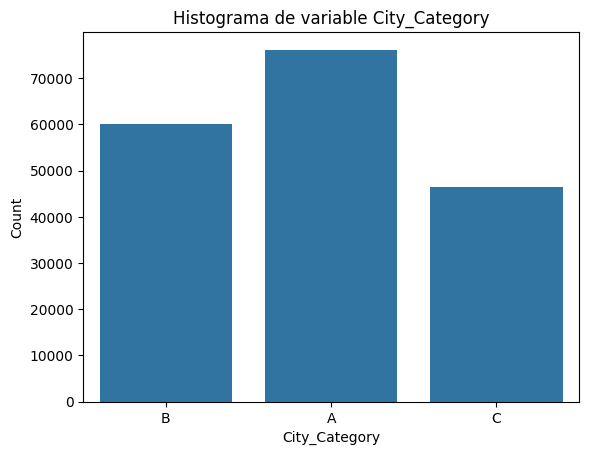

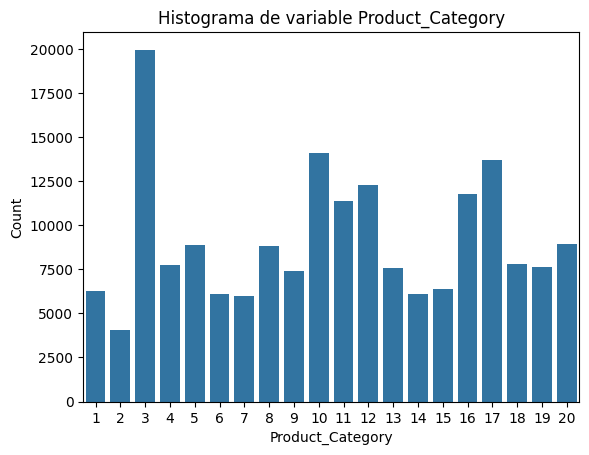

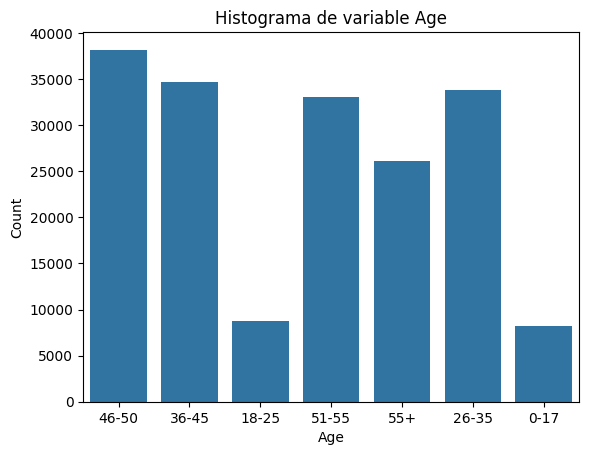

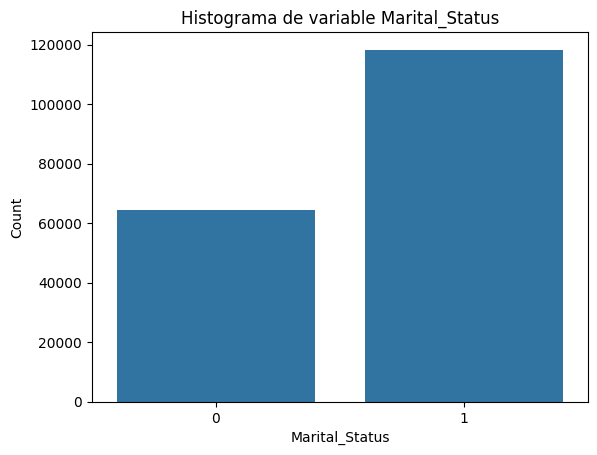

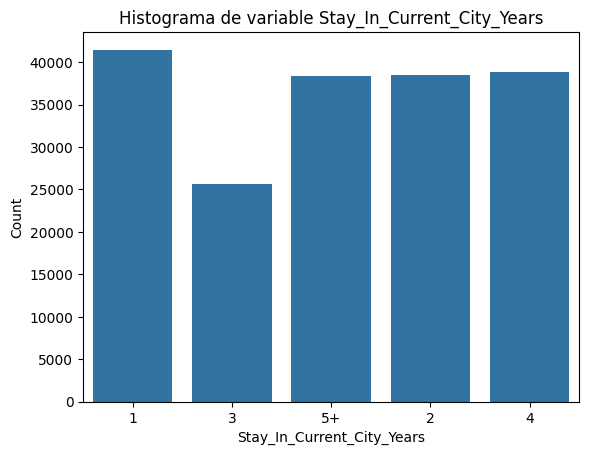

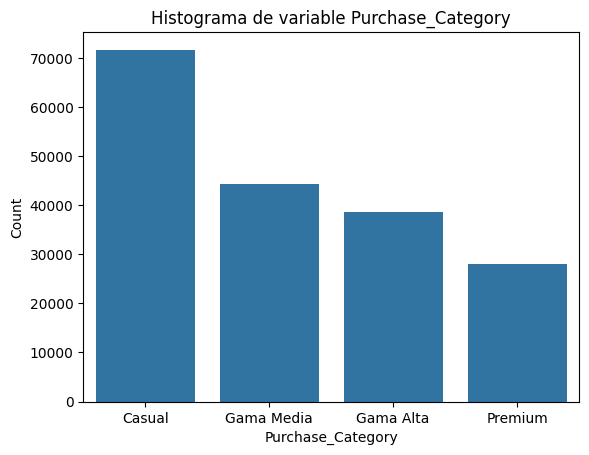

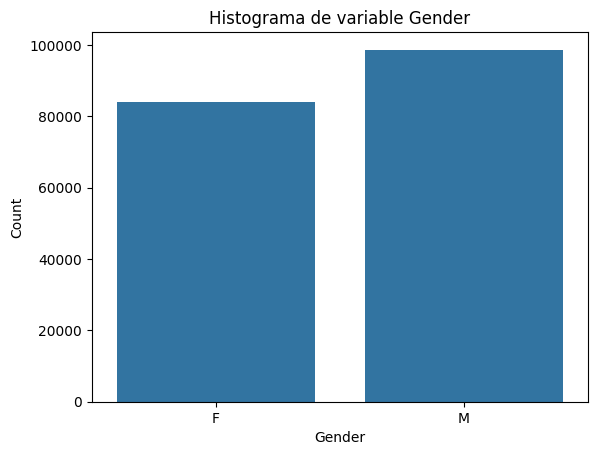

In [ ]:
for col in columnas_a_graficar:
  graficar_distribucion_histograma(data=dataset, col=col, titulo=f"Histograma de variable {col}", xlabel=col, rotation=0)

Como se puede observar, la mayoría de las columnas analizadas tienen están balanceadas, a excepción de:

- Marital_Status
  - El valor `1` tiene $118324$ registros, mientras que `0` tiene $64397$.
- Age
  - La mayoría de los valores tienen aproximadamente $30000$ registros (`55+` tiene $26139$) pero `18-25` tiene $8798$ registros y `0-17` tiene $8188$ registros.
- Purchase_Category
  - La categoría con mayor cantidad de registros es `Casual` con $71698$ registros. El resto se encuentran entre $20000$ y $40000$.

### Definición de técnicas de encoding

Estas son las técnicas de encoding que se aplicarán sobre cada columna del dataset:



| Columna | Técnia | Detalles |
| --- | --- | --- |
| User_ID | No se aplicará encoding | Hay una gran cantidad de valores únicos. Hasing encoding podría causar colisiones, además de requerir muchas columnas. |
| Product_ID | No se aplicará encoding | Hay una gran cantidad de valores únicos. Hasing encoding podría causar colisiones, además de requerir muchas columnas. |
| Age | Frequency encoding | Tenemos $7$ categorías, y resulta poco conveniente utilizar One-Hot encoding. |
| Gender | One-Hot encoding | Solamente hay $2$ categorías. |
| Marital_Status | One-Hot encoding | Solamente hay $2$ categorías. |
| City_Category | One-Hot encoding | Solamente hay $3$ categorías. |
| Stay_In_Current_City_Years | Frequency encoding | Tenemos $5$ categorías, y resulta poco conveniente utilizar One-Hot encoding. |
| Product_Category | Frequency encoding | Hay $20$ categorías, y resulta poco conveniente utilizar One-Hot encoding. |
| Product_Subcategory_1 | Frequency encoding | Hay $34$ ($35$ con "N/A") categorías, y resulta poco conveniente utilizar One-Hot encoding. |
| Product_Subcategory_2 | Frequency encoding | Hay $17$ ($18$ con "N/A") categorías, y resulta poco conveniente utilizar One-Hot encoding. |
| Purchase_Category | Label encoding | Ya que es nuestro target. |

Estas técnicas serán aplicadas luego de hacer un split en train y test.

### Split en train y *test*

En esta sección se hizo un split del dataset en *train* y *test*, siendo *test* un total del $30\%$ del dataset original.

Lo importante a remarcar es que la variable *target* `Purchase_Category` está desbalanceada en el dataset de *train*, por lo cual se deberá balancear en futuros pasos.

In [ ]:
TARGET = "Purchase_Category"
TEST_SIZE = 0.3
RANDOM_STATE = 323123

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(dataset.drop(columns=TARGET),
                                                    dataset[TARGET],
                                                    random_state=RANDOM_STATE,
                                                    test_size=TEST_SIZE,
                                                    stratify=dataset[TARGET])

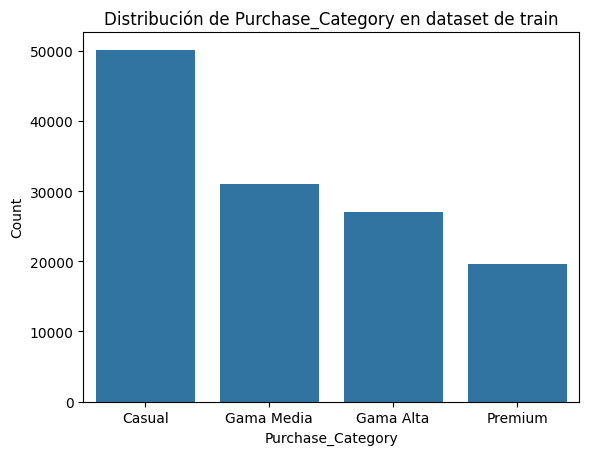

In [ ]:
titulo = f"Distribución de {TARGET} en dataset de train"
graficar_distribucion_histograma(pd.DataFrame(y_train, columns=[TARGET]),
                                 col=TARGET, titulo=titulo,
                                 xlabel=TARGET, rotation=0)

In [ ]:
# Se libera memoria
del dataset

### Preparación del dataset

En esta sección se trabaja sobre los dataset de *train* y *test* de la siguiente manera:

1. Encoding
   - `Frecuency encoding` en las columnas *Age*, *Stay_In_Current_City_Years*, *Product_Category*, *Product_Subcategory_1*, *Product_Subcategory_2*.
   - `One Hot encoding` en las columnas *Gender*, *Marital_Status*, *City_Category*.
   - `Label encoding` sobre la variable target *Purchase_Category*.
1. Normalización
   - Se normalizan los valores resultantes de las columnas codificadas por `Frecuency encoding` mediante un *StandardScaler*.
   - Las features resultantes de `One Hot encoding` no son escaladas, ya que solamente habrá $0$ y $1$.
   - Los valores resultantes del codificado de la variable target mediante `Label encoding` no requiren escalado.
1. Creación de *Dataframe procesado*
   - Corresponde a los dataframes de *train* y *test* con features codificadas y normalizadas.
   - El punto a resaltar radica en la obtención de las columnas generadas por el `One Hot encoder`.
   - Como este encoder se creó con la opción `drop="first"`, la cantidad de columnas creadas para cada feature es igual a su cardinalidad menos uno.
   - Por esto se crean una sola feature para `Gender` (cardinalidad original de $2$), una sola feature para `Marital_Status` (cardinalidad original igual a $2$) y dos features para `City_Category` (originalmente, cardinalidad $3$).
1. Se agregan features al *Dataframe procesado*
   - Se agregan las columnas `User_ID` y `Product_ID` *sin procesar* al dataframe de *train* y *test* luego de aplicar `Frecuency` y `One Hot encoding`.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder, FunctionTransformer

In [ ]:
# Listas de columnas para cada tipo de encoding
otras_cols = ["User_ID", "Product_ID"]
frequency_encoding_cols = ["Age", "Stay_In_Current_City_Years", "Product_Category", "Product_Subcategory_1", "Product_Subcategory_2"]
one_hot_encoding_cols = ["Gender", "Marital_Status", "City_Category"]
label_encoding = [TARGET]

In [ ]:
# Función para forzar el tipo de dato a string
def to_string(X):
    return X.astype(str)

In [ ]:
# Definición de encoders
transformar_frecuentes = Pipeline(steps=[
    ("to_str", FunctionTransformer(to_string, validate=False)),
    ("fre_encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ("scaler", StandardScaler())
])

transformar_one_hot = Pipeline(steps=[
    ("onehot_encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("freq", transformar_frecuentes, frequency_encoding_cols),
        ("onehot", transformar_one_hot, one_hot_encoding_cols)
    ],
    remainder="drop"
)

In [ ]:
pipeline = Pipeline(steps=[("preprocessor", preprocessor)])
pipeline.fit(X_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('freq',
                                                  Pipeline(steps=[('to_str',
                                                                   FunctionTransformer(func=<function to_string at 0x7d4f07bfe480>)),
                                                                  ('fre_encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Stay_In_Current_City_Years',
                                                   'Product_Category',
                                                   'Product_Subcategory_1',
                                                   'Product_Subcategory_2']),
                                                 ('onehot',
                                                  Pipeline(steps=[('onehot_encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Marital_Status',
                                                   'City_Category'])]))])

In [ ]:
X_train_pipeline = pipeline.transform(X_train)
X_test_pipeline = pipeline.transform(X_test)

In [ ]:
# Obtenemos los nuevos nombres de las columnas procesados por One-Hot encoding.
one_hot_new_names = pipeline.named_steps["preprocessor"].named_transformers_["onehot"].named_steps["onehot_encoder"].get_feature_names_out(one_hot_encoding_cols)

In [ ]:
new_features_names = (
    list(frequency_encoding_cols) +
    list(one_hot_new_names)
)

In [ ]:
X_train_procesado = pd.DataFrame(X_train_pipeline, columns=new_features_names)
X_test_procesado = pd.DataFrame(X_test_pipeline, columns=new_features_names)

In [ ]:
# El reset_index es necesario para actualizar correctamente los nuevos valores, sino genera nulos
X_train = X_train.reset_index()
X_test = X_test.reset_index()

In [ ]:
# Se agregan las columnas "User_ID", "Product_ID" a los datasets procesdos por pipelines
for col in otras_cols:
  X_train_procesado[col] = X_train[col]
  X_test_procesado[col] = X_test[col]

In [ ]:
# Finalmente, codificamos la variable target mediante un Label Encoder
labelEncoder = LabelEncoder()

y_train_encoded = labelEncoder.fit_transform(y_train)
y_test_encoded = labelEncoder.transform(y_test)

y_train_procesado = pd.DataFrame(y_train_encoded, columns=[TARGET])
y_test_procesado = pd.DataFrame(y_test_encoded, columns=[TARGET])

In [ ]:
# Liberamos memoria
del X_train_pipeline, X_test_pipeline, y_train_encoded, y_test_encoded, pipeline, preprocessor, X_train, X_test

import gc
gc.collect()

17465

### Tratamiento de desbalance

En esta sección se implementa la técnica de `SMOTE` (más precisamente, Smotenc, ya que el target es categórico) para tratar el desbalance de la variable target en el dataframe de *train*.

Al aplicar esta técnica en el dataframe de *train* se pasan de tener los `127904` registros originales desbalanceados (respecto al target) a `200752` registros *balanceados*.

En el siguiente gráfico se puede observar la distribución de la variable target antes de aplicar la técnica de `SMOTE`.

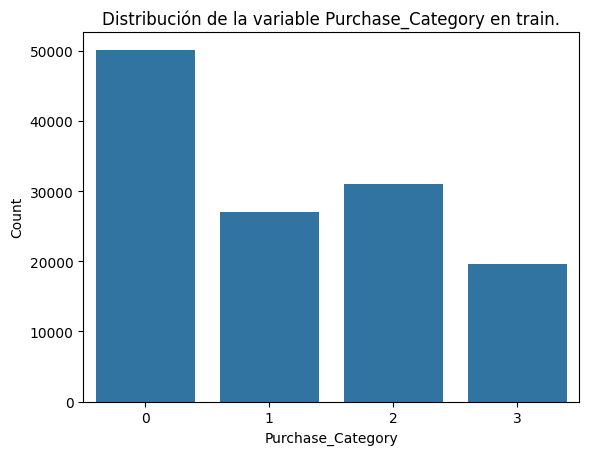

In [ ]:
graficar_distribucion_histograma(data=y_train_procesado, col=TARGET, titulo=f"Distribución de la variable {TARGET} en train.", xlabel=TARGET, rotation=0)

In [ ]:
from imblearn.over_sampling import SMOTENC

In [ ]:
# Índices de User_ID y Product_ID
indices_features_categoricas = [10]

In [ ]:
smotenc = SMOTENC(categorical_features=indices_features_categoricas, random_state=RANDOM_STATE)

In [ ]:
X_train_smote, y_train_smote = smotenc.fit_resample(X_train_procesado, y_train_procesado[TARGET])

En el siguiente gráfico se puede observar la distribución de la variable target **después** de aplicar la técnica de `SMOTE`.

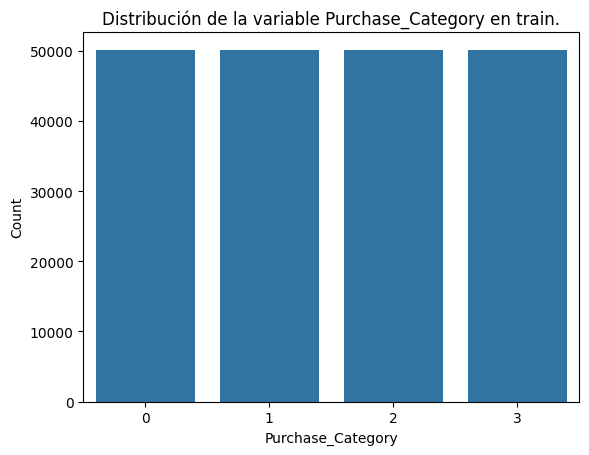

In [ ]:
graficar_distribucion_histograma(data=pd.DataFrame(y_train_smote, columns=[TARGET]), col=TARGET, titulo=f"Distribución de la variable {TARGET} en train.", xlabel=TARGET, rotation=0)

### Creación de datasets finales de train y test

In [ ]:
X_train_final = X_train_smote.copy()
X_test_final = X_test_procesado.copy()

In [ ]:
y_train_final = pd.DataFrame(y_train_smote, columns=[TARGET])
y_test_final = y_test_procesado.copy()

In [ ]:
# Liberamos memoria
del X_train_smote, X_test_procesado, y_train_smote, y_test_procesado

## 2b) Modelo de deep learning sin embeddings

En este punto se trabaja con un modelo de deep learning sin embeddings.

- En la sección `Definición del dataset` se crea el `ComprasDataset`, que será utilizado por PyTorch para crear los datasets de *train* y *validation*.
- En la sección de `Definición del dataset para optimización de hiperparámetros` se crean un dataset de *train* y *validation* específicos para optimizar hiperparámetros en función del dataset de *train* creado en la sección anterior. Esto permite evitar que haya data-leakage al buscar los mejores hiperparámetros.
- En la sección de `Definición del modelo` se crea la clase que representa el modelo de deep learning sin embeddings.
- En la sección de `Función para Training Loopp` se define y *se explica* el ***proceso de iteración*** con el que se entrena nuestro modelo.
- En la sección `Optimización de hiperparámetros` se crean las funciones necesarias para la búsqueda de hiperparámetros mediante el framework optuna. ***NOTA***: este proceso suele demorar bastante tiempo, aproximadamente `40` minutos.
- En la sección de `Instanciación del modelo` se crea el modelo de deep learning con los mejores hiperparámetros, como así también un optimizador y una función de pérdida/costo.
- En la sección `training loop` se ejecuta el loop de entrenamiento, utilizando los objetos creados en las secciones anteriores. ***NOTA***: tener en cuenta que este proceso puede demorar varios minutos.
- En la sección de `Gráficos y métricas` se presentan los gráficos de comparación de métricas como loss, accuracy y f1 vs epochs, tanto para *train* como para *validate*. También se muestran los valores obtenidos para $f1$ y $accuracy$ del modelo.
- En la sección de `matriz de confusión` se muestra la matriz de confusión absoluta y normalizada por fila.
- Finalmente, en la sección `Conclusiones` se resume todo lo realizado en este punto, agregando conclusiones sobre los resultados obtenidos.

### Imports

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn import metrics

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 18.7 MB/s eta 0:00:00


In [ ]:
from torchmetrics.classification import F1Score

### Definición del dataset

En esta sección se crea la clase `ComprasDataset`, que será utilizada al trabajar con PyTorch.

Además, se descartan las columnas `User_ID` y `Product_ID`, tal como se establece en la consigna.

Luego, mediante la clase `DataLoader` se crean los datasets de *train* y *validation*, con un *batch-size* de $256$.

In [ ]:
class ComprasDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, index):
    return np.array(self.X.loc[index,:]), np.array(self.y[index])

In [ ]:
# Se eliminan las columnas según lo indicado en el enunciado
cols_to_drop = ["User_ID", "Product_ID"]

In [ ]:
# Se crean los datasets de train y validation
dataset_train = ComprasDataset(X_train_final.drop(columns=cols_to_drop), np.array(y_train_final[TARGET]))
dataset_validation = ComprasDataset(X_test_final.drop(columns=cols_to_drop), np.array(y_test_final[TARGET]))

In [ ]:
# Tenemos 200752 registros en train y 54817 en validation
BATCH_SIZE = 256
# Se crean los dataloaders para trabajar con batches
dataloader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
dataloader_validation = DataLoader(dataset_validation, batch_size=BATCH_SIZE)

In [ ]:
batch = next(iter(dataloader_train))

### Definición del dataset para optimización de hiperparámetros

En este modelo se utilizarán técnicas de optimización de hiperparámetros.

Para evitar que haya *data leakage*, se opta por crear un dataset de train y validation a partir del dataset de train.

Es decir, de un dataset original obtenemos el dataset de train y validation. Luego, a partir de este dataset de *train* generamos un dataset de *train_cv* y *validation_cv* para optimizar hiperparámetros. Este último split será también del 30%.

A la hora de crear los datasets, se utilizan las clases de `ComprasDataset` y `Dataloader`, con un batch-size de 256.

In [ ]:
# Hacemos split del dataset de train para tener un subset de train y test que
# se utilizará para optimizar hiperparámetros
X_train_final_cv = X_train_final.copy()
X_train_final_cv[TARGET] = y_train_final[TARGET].copy()

X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X_train_final_cv.drop(columns=TARGET),
                                                    X_train_final_cv[TARGET],
                                                    random_state=RANDOM_STATE,
                                                    test_size=TEST_SIZE,
                                                    stratify=X_train_final_cv[TARGET])

# Reseteamos los índices de los datasets de features
X_train_cv = X_train_cv.reset_index()
X_train_cv.drop(columns="index", inplace=True)
X_test_cv = X_test_cv.reset_index()
X_test_cv.drop(columns="index", inplace=True)
y_train_cv = y_train_cv.reset_index()
y_train_cv.drop(columns="index", inplace=True)
y_test_cv = y_test_cv.reset_index()
y_test_cv.drop(columns="index", inplace=True)

# Se crean los datasets de train y validation
dataset_train_cv = ComprasDataset(X_train_cv.drop(columns=cols_to_drop), np.array(y_train_cv[TARGET]))
dataset_validation_cv = ComprasDataset(X_test_cv.drop(columns=cols_to_drop), np.array(y_test_cv[TARGET]))

dataloader_train_cv = DataLoader(dataset_train_cv, batch_size=BATCH_SIZE, shuffle=True)
dataloader_validation_cv = DataLoader(dataset_validation_cv, batch_size=BATCH_SIZE)

batch_cv = next(iter(dataloader_train_cv))

# Liberamos memoria
del X_train_final_cv, X_train_cv, X_test_cv, y_train_cv, y_test_cv

### Definición del modelo

Se crea el modelo de deep learning `ComprasClassifier` sin embeddings.

Este tendrá tres capas ocultas, ademas de tres funciones de activación diferentes.

Si bien se estudió el uso de capas de `drop out`, estas se descartaron, ya que los resultados NO mejoraron al modelo actual.

In [ ]:
class ComprasClassifier(nn.Module):
  def __init__(
      self,
      num_inputs: int,
      num_outputs: int,
      num_hidden: int,
      num_hidden_2: int,
      num_hidden_3: int,
      activation_function: nn.Module = nn.Tanh,
      activation_function_2: nn.Module = nn.Tanh,
      activation_function_3: nn.Module = nn.Tanh,
  ):
    super().__init__()

    self.linear_1 = nn.Linear(num_inputs, num_hidden)
    self.activation_1 = activation_function()
    self.linear_2 = nn.Linear(num_hidden, num_hidden_2)
    self.activation_2 = activation_function_2()

    self.linear_3 = nn.Linear(num_hidden_2, num_hidden_3)
    self.activation_3 = activation_function_3()
    self.linear_final = nn.Linear(num_hidden_3, num_outputs)

  def forward(self, X):
    X = self.linear_1(X)
    X = self.activation_1(X)

    X = self.linear_2(X)
    X = self.activation_2(X)

    X = self.linear_3(X)
    X = self.activation_3(X)

    X = self.linear_final(X)
    return X

### Función para Training Loop

En esta sección se define una función que se utilizará como proceso de iteración para entrenar a nuestro modelo.

Como parámetros, recibe al modelo, un optimizador, una función de costo, la cantidad de outputs que debe generar, los datasets de *train* y *validation*, y la cantidad de epochs.

Este algoritmo se define de esta manera:

- Por cada epoch, se realiza lo siguiente:
  - Ejecuta el ***Loop dataset de train***
  - Se calculan las métricas de loss, f1 y accuracy en *train* por cada *epoch*.
  - Ejecuta el ***Loop dataset de validation***
  - Se calculan las métricas de loss, f1 y accuracy en *validation* por cada *epoch*.

***Loop dataset de train*** </br>
- En el loop por batch del dataset de *train* es donde se entrena el modelo. </br>
- Primero, se utiliza la función de `optimizer.zero_grad()` para asegurarse que se reseteen los gradientes con los que el optimizador trabajo. </br>
- Luego, se realizan predicciones en función de los datos del batch y del modelo. Es decir, aplica la arquitecura que definimos en la clase `ComprasClasiffier`</br>
- El siguiente paso consta de calcular el costo o pérdida entre los valores reales y las predicciones.</br>
- Posteriormente se realiza el *backward pass*, que es cuando nuestro modelo "aprende" o realiza ajustes en función del *optimizador* y la función de costos definidas.
- Finalmente, se calculan las métricas de accuracy y f1 para el **batch** de *train*.

***Loop dataset de validation*** </br>
- Este loop comienza desactivando el tracking del gradiente.
- Luego, realiza predicciones en función de los datos del batch y el modelo.
- Finalmente, se calcula las métricas de accuracy, f1, y los para el **batch** de *validation*.

Las características generales las podemos resumir en:

- Al trabajar en batches de *train* y *validation* por separado, podemos obtener métricas con poco ruido en cada batch.
- Al dividir en *train* y *validation*, podemos asegurar que en la etapa de entrenamiento si se calcule el gradiente, mientras que en la etapa de *validation* no, obteniendo métricas más precisas o cercanas a la realidad.
- Al utilizar epochs, podemos reducir aún más el error/mejorar las métricas del algoritmo, ya que nuestro modelo, en conjunto con el optimizador, van "aprendiendo" o ajustando mejor las predicciones.

In [ ]:
from torch._prims_common import Tensor

def train_validate_loop(model, optimizer, loss_function, num_outputs,
                        dataloader_train, dataloader_validation, epochs=100):
  train_loss_by_epoch=[]
  valid_loss_by_epoch=[]

  train_f1_by_epoch = []
  valid_f1_by_epoch = []

  train_accuracy_by_epoch = []
  valid_accuracy_by_epoch = []

  device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

  for epoch in range(epochs):
    ############### Entrenamiento ###############
    model.train(True)

    train_loss, train_f1, train_accuracy = [], [], []

    for idx, data in enumerate(dataloader_train):
      # X e y para el batch de entrenamiento
      x_batch, y_batch = data

      x_batch = x_batch.to(device).float()
      y_batch = y_batch.to(device)

      ##### Forward pass #####
      optimizer.zero_grad()
      predicciones = model(x_batch)
      predicciones = predicciones.squeeze(dim=1).to(device)

      ##### Compute Loss #####
      loss = loss_function(predicciones, y_batch)

      ##### Backward pass #####
      loss.backward()
      optimizer.step()

      ##### Tracking de métricas por batch #####
      batch_loss = loss.item()
      # train_loss += batch_loss
      train_loss.append(batch_loss)

      # Cálculo de accuracy
      if predicciones.ndim == 2:  # Softmax case
          preds_classes = predicciones.argmax(dim=1)
      else:  # Sigmoid case (binary classification)
          preds_classes = (predicciones > 0.5).long()

      train_correct = (preds_classes == y_batch).sum().item()
      train_samples = y_batch.size(0)
      train_accuracy.append(train_correct/train_samples)

      # Cálculo de f1-score
      # To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  #f1_metric.update(torch.tensor(preds_classes).to(device), torch.tensor(y_batch).to(device))
      f1_metric = F1Score(task="multiclass", num_classes=num_outputs).to(device)
      f1_metric.update(torch.tensor(preds_classes).to(device), torch.tensor(y_batch).to(device))
      train_f1.append(f1_metric.compute().item())

    # Agregamos las métricas del epoch de train en las listas
    train_loss_by_epoch.append(np.mean(train_loss))
    train_f1_by_epoch.append(np.mean(train_f1))
    train_accuracy_by_epoch.append(np.mean(train_accuracy))

    ############### Validación ###############
    model.eval()

    valid_loss, valid_f1, valid_accuracy = [], [], []

    all_preds = torch.tensor([])
    all_targets = torch.tensor([])

    with torch.no_grad(): # Se deshabilita el tracking de gradiente
      for data in dataloader_validation:
        x_batch, y_batch = data
        x_batch = x_batch.to(device).float()
        y_batch = y_batch.to(device)

        # Predicciones
        predicciones = model(x_batch)
        predicciones = predicciones.squeeze(dim=1).to(device)

        all_preds = torch.cat((all_preds, predicciones))
        all_targets = torch.cat((all_targets, y_batch))

        # Cálculo de función de perdida (Loss)
        loss = loss_function(predicciones, y_batch)
        # valid_loss += loss.item()
        valid_loss.append(loss.item())

        # Cálculo de accuracy
        if predicciones.ndim == 2:  # Softmax case
            preds_classes = predicciones.argmax(dim=1)
        else:  # Sigmoid case (binary classification)
            preds_classes = (predicciones > 0.5).long()
        valid_correct = (preds_classes == y_batch).sum().item()
        valid_samples = y_batch.size(0)

        valid_accuracy.append(valid_correct/valid_samples)

        # Cálculo de f1-score
        # To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  #f1_metric.update(torch.tensor(preds_classes).to(device), torch.tensor(y_batch).to(device))
        f1_metric = F1Score(task="multiclass", num_classes=num_outputs).to(device)
        f1_metric.update(torch.tensor(preds_classes).to(device), torch.tensor(y_batch).to(device))
        valid_f1.append(f1_metric.compute().item())

    # if torch.cuda.is_available():
    #     device = 'cuda'
    # else:
    #     device = 'cpu'
    # Agregamos las métricas del epoch de validacion en las listas
    valid_loss_by_epoch.append(np.mean(valid_loss))
    valid_f1_by_epoch.append(np.mean(valid_f1))
    valid_accuracy_by_epoch.append(np.mean(valid_accuracy))

  return train_loss_by_epoch, train_f1_by_epoch, train_accuracy_by_epoch, valid_loss_by_epoch, valid_f1_by_epoch, valid_accuracy_by_epoch, all_preds, all_targets

In [ ]:
def get_activation_function_by_str(act_func: str):
  activation_function = None
  match act_func:
    case "Tanh":
      activation_function = nn.Tanh
    case "GELU":
      activation_function = nn.GELU
    case "LeakyReLU":
      activation_function = nn.LeakyReLU
    case _: # ReLU
      activation_function = nn.ReLU

  return activation_function

### Optimizacion de hiperparámetros

En esta sección se definen los métodos que se utilizarán para optimizar los hiperparámetros de nuestro modelo utilizando `optuna` (búsqueda bayesiana).

El proceso consta de ejecutar una función objetivo, la cual se encarga de crear una instancia del modelo `ComprasClasifier`, la cual será entrenada mediante el loop definido en la sección anterior (`Función de train validate loop`).

A fin de evitar que haya data leakage, se utilizan los datasets definidos en la sección de `Definición del dataset para optimización de hiperparámetros`.

En cuanto a los hiperparámetros estudiados, estos son:

***Hiperparámetros del modelo***
- Funciones de activación: para las tres capas ocultas, se estudiarán `Tanh`, `ReLU`, `GELU` y `LeakyReLU`.
- Tamaño de las capas ocultas del modelo: para las tres capas ocultas, se estudiarán valores entre 1 y 30.

***Hiperparámetros del optimizador***
Se estudiará un optimizador ***Adam***.
El hiperparámetro definido es el *learning rate*, con los valores de 0.01, 0.005, 0.001, 0.0005, 0.0001.

***Resultados***

El modelo `ComprasClassifier`, con optimizador ***Adam*** y función de pérdida ***CrossEntropyLoss*** obtuvo los siguiente mejores hiperparámetros, al realizar 30 iteraciones de optuna, en donde en cada iteración se realizan 5 epochs.

- Cantidad de neuronas de salida de la capa oculta 1: `26`.
- Función de activación de la capa oculta 1: `LeakyReLU`.
- Cantidad de neuronas de salida de la capa oculta 2: `24`.
- Función de activación de la capa oculta 2: `ReLU`.
- Cantidad de neuronas de salida de la capa oculta 3: `30`.
- Función de activación de la capa oculta 3: `GELU`.
- Learning Rate para optimizador Adam: `0.01`.

#### Instalación de optuna

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 20.0 MB/s eta 0:00:00


In [ ]:
import optuna

#### Definición de la función objetivo

In [ ]:
def objective(trial):
    learning_rate = trial.suggest_categorical('lr', [0.01, 0.005, 0.001,
                                                     0.0005, 0.0001])
    hidden_size = trial.suggest_int('hidden_size', 1, 30)
    activation_function = trial.suggest_categorical('activation_function',
                                                    ["Tanh", "ReLU", "GELU", "LeakyReLU"])

    hidden_size_2 = trial.suggest_int('hidden_size_2', 1, 30)
    activation_function_2 = trial.suggest_categorical('activation_function_2',
                                                    ["Tanh", "ReLU", "GELU", "LeakyReLU"])

    hidden_size_3 = trial.suggest_int('hidden_size_3', 1, 30)
    activation_function_3 = trial.suggest_categorical('activation_function_3',
                                                    ["Tanh", "ReLU", "GELU", "LeakyReLU"])

    act_func = get_activation_function_by_str(activation_function)
    act_func_2 = get_activation_function_by_str(activation_function_2)
    act_func_3 = get_activation_function_by_str(activation_function_3)
    epochs = 5

    num_outputs = len(y_train_final[TARGET].unique())

    model = ComprasClassifier(
        num_inputs=X_train_final.shape[1] - len(cols_to_drop),
        num_outputs=num_outputs,
        num_hidden=hidden_size,
        num_hidden_2=hidden_size_2,
        num_hidden_3=hidden_size_3,
        activation_function=act_func,
        activation_function_2=act_func_2,
        activation_function_3=act_func_3,
    )

    device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_function = nn.CrossEntropyLoss()

    _, _, _, val_loss, val_f1, val_acc, _, _ = train_validate_loop(model=model,
                                                             optimizer=optimizer,
                                                             loss_function=loss_function,
                                                             num_outputs=num_outputs,
                                                             dataloader_train=dataloader_train_cv,
                                                             dataloader_validation=dataloader_validation_cv,
                                                             epochs=epochs)
    return np.mean(val_loss)

#### Búsqueda de mejores hiperparámetros

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)
print("Mejores hiperparámetros:", study.best_params)

[I 2025-09-30 01:03:33,689] A new study created in memory with name: no-name-dd80ea08-c184-441e-b513-808e915d0107
/tmp/ipython-input-1121941733.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  f1_metric.update(torch.tensor(preds_classes).to(device), torch.tensor(y_batch).to(device))
/tmp/ipython-input-1121941733.py:108: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  f1_metric.update(torch.tensor(preds_classes).to(device), torch.tensor(y_batch).to(device))
[I 2025-09-30 01:05:04,208] Trial 0 finished with value: 1.1680976332244226 and parameters: {'lr': 0.005, 'hidden_size': 14, 'activation_function': 'GELU', 'hidden_size_2': 27, 'activation_function_2': 'GELU', 'hidden_size_3': 1, 'ac

Mejores hiperparámetros: {'lr': 0.01, 'hidden_size': 26, 'activation_function': 'LeakyReLU', 'hidden_size_2': 24, 'activation_function_2': 'ReLU', 'hidden_size_3': 30, 'activation_function_3': 'GELU'}


```
Mejores hiperparámetros: {'lr': 0.01, 'hidden_size': 26, 'activation_function': 'LeakyReLU', 'hidden_size_2': 24, 'activation_function_2': 'ReLU', 'hidden_size_3': 30, 'activation_function_3': 'GELU'}
```



### Instanciación del modelo

En esta sección se instancia el modelo de `ComprasClassifier` utilizando los mejores hiperparámetros encontrados en la sección anterior.

Además, se crean los siguientes objetos que serán utilizados durante el loop de entrenamiento:

- *loss function*: se crea una `CrossEntropyLoss`, ya que es una función de pérdida/costo ideal para las tareas de entrenamiento de clasificación con más de dos clases (en nuestro caso de estudio tenemos *4* clases).
- *Optimizer*: se crea el optimizador de `Adam`, el cual será utilizado para actualizar los parámetros del modelo en función de los gradientes de la función de pérdida/costo.

In [ ]:
num_features = X_train_final.shape[1] - len(cols_to_drop)
num_outputs = len(y_train_final[TARGET].unique())
NUM_HIDDEN = study.best_params["hidden_size"]
activation_function = get_activation_function_by_str(study.best_params["activation_function"])

In [ ]:
NUM_HIDDEN_2 = study.best_params["hidden_size_2"]
activation_function_2 = get_activation_function_by_str(study.best_params["activation_function_2"])

In [ ]:
NUM_HIDDEN_3 = study.best_params["hidden_size_3"]
activation_function_3 = get_activation_function_by_str(study.best_params["activation_function_3"])

In [ ]:
model = ComprasClassifier(
    num_inputs=num_features,
    num_outputs=num_outputs,
    num_hidden=NUM_HIDDEN,
    activation_function=activation_function,
    num_hidden_2=NUM_HIDDEN_2,
    activation_function_2=activation_function_2,
    num_hidden_3=NUM_HIDDEN_3,
    activation_function_3=activation_function_3,
)

In [ ]:
# Fuentes:
# https://www.cs.toronto.edu/~lczhang/321/tut/tut04.pdf
# https://discuss.pytorch.org/t/loss-function-for-multi-class-with-probabilities-as-output/60866
loss_function = torch.nn.CrossEntropyLoss()
LEARNING_RATE_ADAM = study.best_params["lr"]
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE_ADAM)

In [ ]:
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
model = model.to(device)

### Training loop

Aquí se ejecuta el loop de entrenamiento, utilizando el modelo con los mejores hiperparámetros, el optimizador de `Adam`, la función de costo de `CrossEntropyLoss` y los dataloaders de *train* y *validation*.

En total, se ejecutarán *100* epochs.

En cada epoch, se implementará un mini-batch para train y validation por separados.

En *train* el modelo irá ajustando sus parámetros, en función de la función de costo y del optimizador, como así también se calcularán métricas asociadas al coste, accuracy y f1 de cada epoch.

En *validate* se calculan las métricas de coste, accuracy y f1 score. Una diferencia que hay respecto a los loops de *train* es que en *validation* NO se calcula el gradiente.

In [ ]:
train_loss, train_f1, train_acc, val_loss, val_f1, val_acc, all_preds, all_targets = train_validate_loop(model=model,
                                                         optimizer=optimizer, num_outputs=num_outputs,
                                                         loss_function=loss_function, dataloader_train=dataloader_train, dataloader_validation=dataloader_validation, epochs=100)

/tmp/ipython-input-1121941733.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  f1_metric.update(torch.tensor(preds_classes).to(device), torch.tensor(y_batch).to(device))
/tmp/ipython-input-1121941733.py:108: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  f1_metric.update(torch.tensor(preds_classes).to(device), torch.tensor(y_batch).to(device))


### Gráficos y métricas

En esta sección se presentan tres gráficos:

1. `Train Loss vs Validation Loss`, para 100 epochs.
1. `Train F1 vs Validation F1`, para 100 epochs.
1. `Train Accuracy vs Validation Accuracy`, para 100 epochs.

El siguiente gráfico corresponde a la comparación del coste o *loss* en *train* vs *validate*, para 100 epochs.

Como se puede observar, la curva correspondiente a *train* es mayor a la curva de *validate*. Esto se debe a que durante la etapa de *train*, el coste o loss se calcula como:

$L_{training} = L_{base} + L_{regularización}$

Donde $L_{base}$ es el coste base definido antes del training loop (CrossEntropyLoss) y $L_{regularización} es el coste de regularización (Adam).

Mientras que el costo de *validate* es:

$L_{validation} = L_{base}$, es decir, solamente considera el coste base.

Otro detalle a observar es que la gráfica de *validate* presenta ciertas oscilaciones. Esto puede deberse al *learning rate* utilizado, que en este caso fue de $0.01$ (optimización de hiperparámetros). Probablemente, con un learning rate menor, se realizarían *saltos* menores en la etapa de aprendizaje, lo cual se traduciría en una curva más suave (y sin picos/oscilaciones) en la etapa de *validate*.

***Fuente***: [Medium Post](https://siddiqueabusaleh.medium.com/why-my-training-loss-is-higher-than-validation-loss-is-the-reported-loss-even-accurate-8843e14a0756)

Text(0, 0.5, 'Loss')

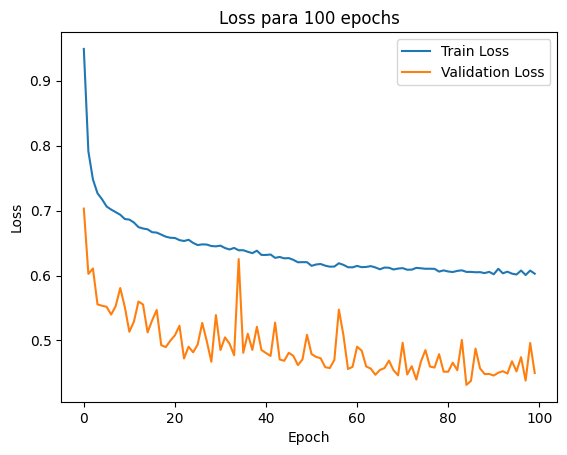

In [ ]:
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend()
plt.title(f"Loss para 100 epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

La siguiente gráfica representa las curvas de F1-score para train y validate, con un total de 100 epochs.

Se observa que la curva de *train* presenta valores menores que la curva de *validate*.

Esto puede deberse a que el modelo está *generalizando* bien.

En cuanto a las oscilaciones de la curva de *validate*, estas se pueden deber al mismo motivo que en el caso de *loss* en validate, es decir, que se utilizó un learning rate alto (o debería haberse utilizado un valor más pequeño).

El valor final alcanzado para ***f1-score*** en *validate* fue de $0.8024$.

Text(0, 0.5, 'F1-score')

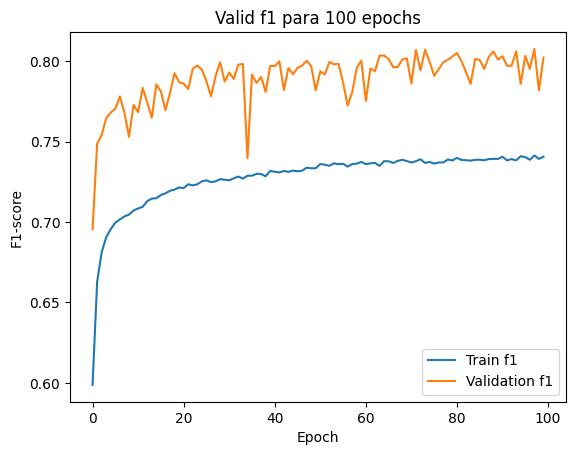

In [ ]:
plt.plot(train_f1, label="Train f1")
plt.plot(val_f1, label="Validation f1")
plt.legend()
plt.title(f"Valid f1 para 100 epochs")
plt.xlabel("Epoch")
plt.ylabel("F1-score")

La siguiente gráfica representa las curvas de accuracy para train y validate, con un total de 100 epochs.

Se observa que la curva de *train* presenta valores menores que la curva de *validate*.

Esto puede deberse a que el modelo está *generalizando* bien.

En cuanto a las oscilaciones de la curva de *validate*, estas se pueden deber al mismo motivo que en el caso de *loss* en validate, es decir, que se utilizó un learning rate alto (o debería haberse utilizado un valor más pequeño).

El valor final alcanzado para ***accuracy*** en *validate* fue de $0.8024$.

Text(0, 0.5, 'Accuracy')

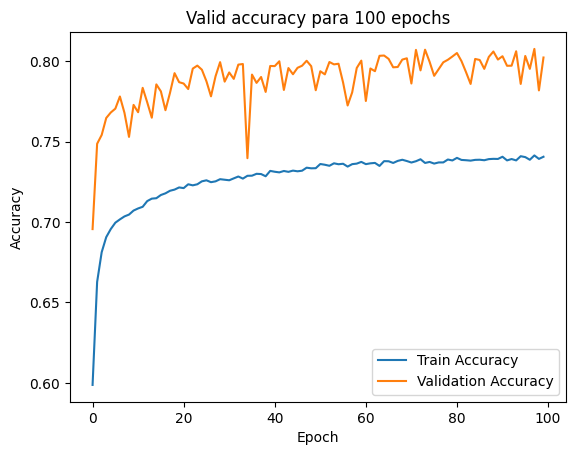

In [ ]:
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend()
plt.title(f"Valid accuracy para 100 epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

In [ ]:
print(f"Valor Máximo de Accuracy alcanzado: {np.round(np.max(val_acc), 4)}")
print(f"Valor Máximo de F1 alcanzado: {np.round(np.max(val_f1), 4)}")

Valor Máximo de Accuracy alcanzado: 0.8077
Valor Máximo de F1 alcanzado: 0.8077


In [ ]:
print(f"Valor Final de Accuracy alcanzado: {np.round(val_acc[-1], 4)}")
print(f"Valor Final de F1 alcanzado: {np.round(val_f1[-1], 4)}")

Valor Máximo de Accuracy alcanzado: 0.8024
Valor Máximo de F1 alcanzado: 0.8024


### Matriz de confusión

En esta sección se presentan dos matrices de confusión.

1. Matriz de confusión absoluta.
1. Matriz de confusión normalizada.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
target_labels = []
for i in range(4):
  target_val = labelEncoder.inverse_transform([i])
  target_labels.append(target_val[0])

In [ ]:
target_labels

['Casual', 'Gama Alta', 'Gama Media', 'Premium']

In [ ]:
cm = confusion_matrix(all_targets, all_preds.argmax(dim=1), labels=y_train_final[TARGET].unique())
print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[ 7634   447   160   193]
 [  346  9718  1557  1658]
 [ 2169  2866  6446   113]
 [  310   820   198 20182]]


A continuación se muestra la matriz de confusión absoluta, calculada a partir de las estimaciones obtenidas en la última iteración sobre el dataset de ***validate***.

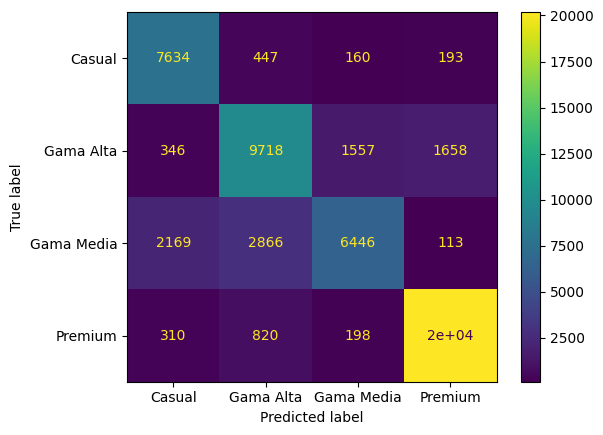

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_labels)
disp.plot()
plt.show()

In [ ]:
cm_normalized_by_row = confusion_matrix(all_targets, all_preds.argmax(dim=1), normalize='true')
print("\nMatriz de confusión normalizada por fila:")
print(cm_normalized_by_row)


Confusion Matrix Normalized by Row:
[[0.93826127 0.00920502 0.0381218  0.0144119 ]
 [0.00974642 0.55597723 0.24719683 0.18707952]
 [0.1248588  0.11725281 0.73183222 0.02605618]
 [0.02288357 0.01897083 0.05299976 0.90514584]]


A continuación se muestra la matriz de confusión normalizada, calculada a partir de las estimaciones obtenidas en la última iteración sobre el dataset de ***validate***.

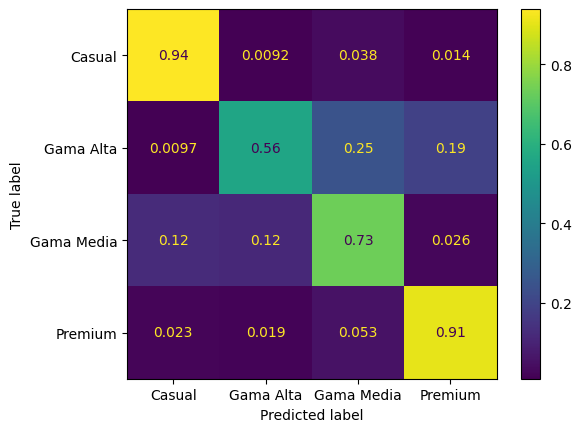

In [ ]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=target_labels)
disp_normalized.plot()
plt.show()

En ambas matrices se observa lo siguiente para cada una de las clases:

- `Casual`: el modelo clasifica correctamente a los clientes categorizados como casuales, más precisamente, al $94\%$ de estos.
- `Gama Alta`: el modelo clasifica correctamente al $56\%$ de los casos. Al $25\%$ de los casos los *confunde* con clientes `Gama Media`, mientras que el $19\%$ los confunde con clientes `Premium`.
- `Gama Media`: el modelo clasifica correctamente al $73\%$ de los casos. Clasifica érroneamente como `Casual` al $12\%$ de los casos, y como `Gama Alta` a otro $12\%$ de los casos.
- `Premium`: el modelo clasifica correctamente al $91\%$ de los casos.

### Conclusiones

En esta sección se creó un modelo de Deep Learning *sin embeddings*, el cual tiene un accuracy final de $0.8024$ y de f1-score de $0.8024$.

Este es un modelo que permite categorizar correctamente (más del $90\%$ de los casos) a los clientes `Casual` y `Premium`, pero al resto de los clientes suele confundirlos con otros tipos.

Por ejemplo, a los clientes `Gama Alta` los confunde el $25\%$ de las veces con `Gama Media` y el $19\%$ a los `Premium`.

Por otro lado, el modelo clasifica a los clientes `Gama Media` con clientes `Premium` el $12\%$ de las veces, como así también con los `Gama Alta` (también el $12\%$).

Como conclusión, podemos decir que este modelo de Deep Learning con tres capas ocultas sin embeddings, con optimización de hiperparámetros, que utiliza el optimizador ***Adam****, una función de pérdida de ***CrossEntropyLoss***, y fue entrenado con un *training* loop de $100$ epochs es bueno para clasificar a los clientes `Casuales` y `Premium`, pero no al resto.

Los motivos por los cuales no clasifique correctamente a las otras dos clases puede deberse al uso de ciertos hioperparámetros al entrenar el modelo, por ejemplo, un learning rate de $0.01$, como así también a no haber utilizado otras técnicas de regularización como ***Adam-Weighted***, o incluso haber aplicado *drop out* en el modelo de Deep learning.

## 2c) Modelo de deep learning con embeddings

En esta sección se estudio y entrena un modelo de deep learning con embeddings.

- En la sección `Definición del dataset` se define el dataset con el cual se trabajará.
- En la sección `Función para Training loop` se define como se realizará el loop de train/validate para nuestro modelo.
- En la sección `Definición del modelo` se crea el modelo `ComprasClassifierWithEmbeddings` con el que se trabajará más adelante. Este modelo es una red neuronal con embeddings para las columasn `User ID` y `Product ID`.
- En la sección `Optimización de hiperparámetros` se buscan los mejores parámetros de la red.
  - Entre estos parámetros se encuentran las ***dimensiones de las capas de embeddings** para User ID y Product ID.
  - ***NOTA***: Este proceso suele demorar entre $40$ y $50$ minutos.
- En la sección `instanciación del modelo` se crea el modelo según los mejores hiperparámetros.
- En la sección `Función de pérdida, optimizador, scheduler` se realiza el loop de entrenamiento, como así también se crean otros objetos útiles que se utilizarán en este proceso.  
- En la sección `Gráficos` se realizan los gráficos por epoch de *loss*, *accuracy* y *f1* para *train* y *validate*.
- En la sección *Matriz de confusión* se muestra la matriz de confusión absoluta y normalizada del modelo.


### imports

In [ ]:
import torch
from typing import Tuple, List, Dict, Optional, Union
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ExponentialLR, CosineAnnealingWarmRestarts

### Definición del dataset

En esta sección se define la clase `ComprasDatasetWithEmbeddings`, que nos permitirá definir el dataset para nuestro modelo de Deep Learning con embeddings.

Se comienza identificando los `User_ID` y `Product_ID` únicos, tanto en train y test. A partir de estos se crea una enumeración, con la cual se "codificará" los valores originales de cada dataset. Esto será útil en etapas posteriores, al trabajar con embeddings.

También se crea la clase `ComprasDatasetWithEmbeddingsCollator`, que será útil a la hora de crear los batches con los que se entrenará el modelo en el loop de entrenamiento (con mini-batch).

In [ ]:
userIdTrain = X_train_final["User_ID"].unique()
userIdTest = X_test_final["User_ID"].unique()
userIds = np.union1d(userIdTrain, userIdTest)

productIdTrain = X_train_final['Product_ID'].unique()
productIdTest = X_test_final['Product_ID'].unique()
productIds = np.union1d(productIdTrain, productIdTest)

In [ ]:
userid2id = {k:i for i, k in enumerate(userIds)}
productid2id = {k:i for i, k in enumerate(productIds)}

In [ ]:
X_train_emb = X_train_final.copy()
X_test_emb = X_test_final.copy()

In [ ]:
X_train_emb["User_ID"] = X_train_emb["User_ID"].apply(lambda x: userid2id[x])
X_test_emb["User_ID"] = X_test_emb["User_ID"].apply(lambda x: userid2id[x])

X_train_emb["Product_ID"] = X_train_emb["Product_ID"].apply(lambda x: productid2id[x])
X_test_emb["Product_ID"] = X_test_emb["Product_ID"].apply(lambda x: productid2id[x])

In [ ]:
y_train_emb = y_train_final.copy()
y_test_emb = y_test_final.copy()

In [ ]:
class ComprasDatasetWithEmbeddings(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, index):
    col_for_embeddings = ["User_ID", "Product_ID"]
    col_no_embeddings = list(set(self.X.columns) - set(col_for_embeddings))

    numerical_features = {
        k: torch.tensor(self.X.loc[index, k], dtype=torch.float32)
        for k in col_no_embeddings
    }

    categorical_features = {
        k: torch.tensor(self.X.loc[index, k], dtype=torch.long)
        for k in col_for_embeddings
    }

    return {
        **categorical_features,
        **numerical_features,
        'label': torch.tensor(self.y[index], dtype=torch.long)
    }

In [ ]:
class ComprasDatasetWithEmbeddingsCollator:
  def __init__(self):
    self.float_features = ['Age', 'Product_Category',
                           'City_Category_C', 'Marital_Status_1',
                           'City_Category_B', 'Product_Subcategory_2',
                           'Stay_In_Current_City_Years', 'Gender_M',
                           'Product_Subcategory_1']
    self.cat_features = ["User_ID", "Product_ID"]
  def __call__(self, batch: List[Dict[str, torch.Tensor]]) -> Tuple[Dict[str, torch.Tensor], torch.Tensor]:
      X_float = torch.stack([
          torch.stack([item[feat] for feat in self.float_features])
          for item in batch
      ]).float()

      X_cat = {
          feat: torch.stack([item[feat] for item in batch]).long()
          for feat in self.cat_features
      }

      y = torch.stack([item['label'] for item in batch]).long()

      return {'X_float': X_float, 'X_cat': X_cat}, y

In [ ]:
train_emb = ComprasDatasetWithEmbeddings(X_train_emb.reset_index(drop=True), y_train_emb["Purchase_Category"])
val_emb = ComprasDatasetWithEmbeddings(X_test_emb.reset_index(drop=True), y_test_emb["Purchase_Category"])

collator = ComprasDatasetWithEmbeddingsCollator()

train_emb_dataloader = DataLoader(train_emb, batch_size=256, shuffle=True, collate_fn=collator)
val_emb_dataloader = DataLoader(val_emb, batch_size=256, shuffle=False, collate_fn=collator)

batch_X, batch_y = next(iter(train_emb_dataloader))
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
batch_X, batch_y = {"X_float": batch_X["X_float"].to(device), "X_cat": {k:v.to(device) for k,v in batch_X["X_cat"].items()}}, batch_y.to(device)

### Funciones útiles

In [ ]:
def get_activation_function_by_str(act_func: str):
  activation_function = None
  match act_func:
    case "Tanh":
      activation_function = nn.Tanh
    case "GELU":
      activation_function = nn.GELU
    case "LeakyReLU":
      activation_function = nn.LeakyReLU
    case _: # ReLU
      activation_function = nn.ReLU

  return activation_function

### Función para Training loop


En esta sección se define una función que se utilizará como proceso de iteración para entrenar a nuestro modelo.

Como parámetros, recibe al modelo, un optimizador, una función de costo, la cantidad de outputs que debe generar, los datasets de *train* y *validation*, y la cantidad de epochs.

Este algoritmo se define de esta manera:

- Por cada epoch, se realiza lo siguiente:
  - Ejecuta el ***Loop dataset de train***
  - Se calculan las métricas de loss, f1 y accuracy en *train* por cada *epoch*.
  - Ejecuta el ***Loop dataset de validation***
  - Se calculan las métricas de loss, f1 y accuracy en *validation* por cada *epoch*.
  - Validación de ***Early Stopping***: en función de los parámetros que recibe esta función, se valida si se debe realizar un early stopping o no, es decir, si se debe finalizar el proceso de entrenamiento antes de ejecutar todos los epochs. Esto depende de si las métricas obtuvieron mejoras entre epochs o no.

***Loop dataset de train*** </br>
- En el loop por batch del dataset de *train* es donde se entrena el modelo. </br>
- Primero, se utiliza la función de `optimizer.zero_grad()` para asegurarse que se reseteen los gradientes con los que el optimizador trabajo. </br>
- Luego, se realizan predicciones en función de los datos del batch y del modelo. Es decir, aplica la arquitecura que definimos en la clase `ComprasClassifierWithEmbeddings`</br>
- El siguiente paso consta de calcular el costo o pérdida entre los valores reales y las predicciones.</br>
- Posteriormente se realiza el *backward pass*, que es cuando nuestro modelo "aprende" o realiza ajustes en función del *optimizador* y la función de costos definidas. Aquí también interviene el *scheduler*, el cual permite adaptar el learning rate al proceso de optimización, de manera que se puede incrementar la performance como así también reducir el tiempo de entrenamiento. Fuente: [Using Learning Rate Schedule in PyTorch training](https://machinelearningmastery.com/using-learning-rate-schedule-in-pytorch-training/).
- Finalmente, se calculan las métricas de accuracy y f1 para el **batch** de *train*.

***Loop dataset de validation*** </br>
- Este loop comienza desactivando el tracking del gradiente.
- Luego, realiza predicciones en función de los datos del batch y el modelo.
- Finalmente, se calcula las métricas de accuracy, f1, y los para el **batch** de *validation*.

Las características generales las podemos resumir en:

- Al trabajar en batches de *train* y *validation* por separado, podemos obtener métricas con poco ruido en cada batch.
- Al dividir en *train* y *validation*, podemos asegurar que en la etapa de entrenamiento si se calcule el gradiente, mientras que en la etapa de *validation* no, obteniendo métricas más precisas o cercanas a la realidad.
- Al utilizar epochs, podemos reducir aún más el error/mejorar las métricas del algoritmo, ya que nuestro modelo, en conjunto con el optimizador, van "aprendiendo" o ajustando mejor las predicciones.
- Al implementar schedulers, podemos lograr que el learning rate se adapte al proceso de optimización, como así también reducir el tiempo de entrenamiento.
- Al implementar early stopping podemos lograr que el proceso de entrenamiento termine antes de llegar al último epoch.


***NOTA***: el código está basado en las notebooks de la [clase 4](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_202503/clase_4/ejercicios/ntb.ipynb) de la materia de *Aprendizaje Produnfo*, *CEIA*, *FIUBA*.

In [ ]:
from tqdm import tqdm

#################### Training Loop ####################
def train_model_embeddings(
    model,
    optimizer,
    train_loader,
    eval_loader,
    loss_module,
    scheduler,
    num_epochs=100,
    patience=5,
    min_delta=0.001,
    num_outputs=4,
    early_stoping=True,
    show_prints=True
):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Variables para Early stopping
    best_eval_loss = float('inf')
    best_eval_accuracy = float(0.0)
    best_eval_f1 = float(0.0)
    patience_counter = 0

    # Acumuladores de métricas finales
    train_loss_by_epoch=[]
    valid_loss_by_epoch=[]

    train_f1_by_epoch = []
    valid_f1_by_epoch = []

    train_accuracy_by_epoch = []
    valid_accuracy_by_epoch = []

    model.to(device)

    for epoch in tqdm(range(num_epochs), desc="Training", disable=(not show_prints)):
        #################### ENTRENAMIENTO ####################
        model.train()
        # Acumuladores de métricas para el epoch
        train_loss, train_f1 = 0.0, 0.0
        train_preds = torch.tensor([])
        train_targets = torch.tensor([])

        for batch_idx, (data, targets) in enumerate(train_loader):
            inputs = {
                "X_float": data["X_float"].to(device),
                "X_cat": {k: v.to(device) for k, v in data["X_cat"].items()}
            }
            targets = targets.to(device)

            # Forward pass
            preds = model(inputs).squeeze(-1)

            # Cálculo de costo/loss
            loss = loss_module(preds, targets)

            # Cálculo de accuracy
            if preds.ndim == 2:
                preds_classes = preds.argmax(dim=1)
            else:
                preds_classes = (preds > 0.5).long()

            # F1
            f1_metric = F1Score(task="multiclass", num_classes=num_outputs).to(device)
            f1_metric.update(preds_classes.detach().clone().to(device), targets.detach().clone().to(device))

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            # Accumulate metrics
            train_loss += loss.item()
            train_f1 += (f1_metric.compute().item())
            train_preds = torch.cat((train_preds, preds))
            train_targets = torch.cat((train_targets, targets))

        # Métricas por epoch
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = metrics.accuracy_score(train_targets, train_preds.argmax(dim=1))
        epoch_train_f1 = train_f1  / len(train_loader)

       #################### Validación ####################
        model.eval()

        # Acumuladores de métricas para el epoch
        eval_loss, eval_f1 = 0.0, 0.0
        all_preds = torch.tensor([])
        all_targets = torch.tensor([])

        with torch.no_grad():
          for data, targets in eval_loader:
              inputs = {
                  "X_float": data["X_float"].to(device),
                  "X_cat": {k: v.to(device) for k, v in data["X_cat"].items()}
              }
              targets = targets.to(device)
              preds = model(inputs).squeeze(-1)

              eval_loss += loss_module(preds, targets).item()

              # Cálculo de accuracy
              if preds.ndim == 2:
                  preds_classes = preds.argmax(dim=1)
              else:
                  preds_classes = (preds > 0.5).long()

              # eval_correct = (preds_classes == targets).sum().item()
              # eval_samples = targets.size(0)
              all_preds = torch.cat((all_preds, preds))
              all_targets = torch.cat((all_targets, targets))

              # F1
              f1_metric = F1Score(task="multiclass", num_classes=num_outputs).to(device)
              f1_metric.update(preds_classes.detach().clone().to(device), targets.detach().clone().to(device))
              eval_f1 += (f1_metric.compute().item())

        epoch_eval_loss = eval_loss / len(eval_loader)
        epoch_eval_acc = metrics.accuracy_score(all_targets, all_preds.argmax(dim=1))
        epoch_eval_f1 = eval_f1  / len(eval_loader)

        train_loss_by_epoch.append(epoch_train_loss)
        valid_loss_by_epoch.append(epoch_eval_loss)

        train_f1_by_epoch.append(epoch_train_f1)
        valid_f1_by_epoch.append(epoch_eval_f1)

        train_accuracy_by_epoch.append(epoch_train_acc)
        valid_accuracy_by_epoch.append(epoch_eval_acc)

        if show_prints:
          print(
              f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} (Accuracy: {epoch_train_acc:.2f}%) (F1: {epoch_train_f1:.2f}%) | "
              f"Val Loss: {epoch_eval_loss:.4f} (Accuracy: {epoch_eval_acc:.2f}%) (F1: {epoch_eval_f1:.2f}%)"
          )

        #################### Early Stopping ####################
        f1_improved = (epoch_eval_f1 > best_eval_f1 + min_delta)
        acc_improved = (epoch_eval_acc > best_eval_accuracy + min_delta)
        loss_improved = (epoch_eval_loss < best_eval_loss - min_delta)

        if early_stoping:
          if loss_improved or f1_improved or acc_improved:
              if f1_improved:
                  best_eval_f1 = epoch_eval_f1
              if acc_improved:
                  best_eval_accuracy = epoch_eval_acc
              if loss_improved:
                  best_eval_loss = epoch_eval_loss

              patience_counter = 0
              # torch.save(model.state_dict(), "best_model.pth")
              if show_prints:
                print(f"New best: Loss={best_eval_loss:.4f}, Accuracy={epoch_eval_acc:.2f}%, F1={epoch_eval_f1:.2f}%")
          else:
              patience_counter += 1
              if patience_counter >= patience:
                  if show_prints:
                    print(f"Early stopping! No improvement for {patience} epochs.")
                    print(f"Final metrics - Loss: {epoch_eval_loss:.4f}, Accuracy: {epoch_eval_acc:.2f}%, F1: {epoch_eval_f1:.2f}%")
                  return train_loss_by_epoch, valid_loss_by_epoch, train_f1_by_epoch, valid_f1_by_epoch, train_accuracy_by_epoch, valid_accuracy_by_epoch, all_preds, all_targets

    return train_loss_by_epoch, valid_loss_by_epoch, train_f1_by_epoch, valid_f1_by_epoch, train_accuracy_by_epoch, valid_accuracy_by_epoch, all_preds, all_targets

### Definición del modelo

Aquí se define el modelo de Deep Learning de `ComprasClassifierWithEmbeddings`.

Este permite definir una cantidad dinámica de capas ocultas/densas, como así también de funciones de activación, siempre y cuando sus dimensiones coincidan.

Además, recibe los parámetros necesarios para definir *embeddings* para las features de `User_ID` y `Product_ID`.

Respecto a las dimensiones de los *embeddings*:

- El parámetro `num_embeddings` será igual al tamaño del diccionario definido para cada *feature* ($17574$ para `User_ID` y $2455$ para `Product_ID`).
  - Esto se debe a que queremos "codificar" o encontrar una representación de tamaño `dim_embedding` de cada uno de estos valores.
- El parámetro `dim_embeddings` se obtendrá mediante la optimización de hiperparámetros, utilizando los valores recomendados por estas heurísticas:
  - $min(n\_cat//2, 50)$. Fuente: [Medium - Embedding of categorical variables for deep learning](https://medium.com/swlh/embedding-of-categorical-variables-for-deep-learning-model-explained-6aa8a1a04603)
  - $min(600, round(1.6 * n\_cat**0.56))$. Fuente: [Size of embedding for categorical variables](https://forums.fast.ai/t/size-of-embedding-for-categorical-variables/42608/2)
  - ***n_cat***: cantidad de categorías distintas en una feature/columna.


Finalmente, se configura para poder utilizar `drop-outs`.

***NOTA***: el código está basado en las notebooks de la [clase 4](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_202503/clase_4/ejercicios/ntb.ipynb) de la materia de *Aprendizaje Produnfo*, *CEIA*, *FIUBA*.

In [ ]:
class ComprasClassifierWithEmbeddings(torch.nn.Module):
  def __init__(
      self,
      userid2id: Dict[str, int],
      productid2id: Dict[str, int],
      userid_dim: Optional[int] = 10,
      product_id_dim: Optional[int] = 10,
      dense_layers: List[int] = [50],
      dropout_rates: Union[float, List[float]] = 0.1,
      n_outputs: int = 4, # En nuestro caso de estudio, el output tiene 4 clases posibles
      use_batch_norm: bool = True,
      activation: str = "ReLU"
  ):
    super().__init__()

    # Capa de embeddings
    self.user_id_embeddings = nn.Embedding(num_embeddings=len(userid2id), embedding_dim=userid_dim)
    self.product_id_embeddings = nn.Embedding(num_embeddings=len(productid2id), embedding_dim=product_id_dim)

    self.total_features = 9 + userid_dim + product_id_dim # 9 features además de userId y productId

    # Configuración de capa densa
    self.dense_layers = dense_layers
    if not dense_layers:
        raise ValueError("Debe haber por lo menos una capa densa")

    # Configuración de dropout
    if isinstance(dropout_rates, float):
        self.dropout_rates = [dropout_rates] * len(dense_layers)
    else:
        if len(dropout_rates) != len(dense_layers):
            raise ValueError("drop_out_rates y dense_layers deben tener la misma longitud.")
        self.dropout_rates = dropout_rates

    # Función de activación
    self.activation = get_activation_function_by_str(activation)()

    # Creación de bloques de capa densa
    self.dense_blocks = nn.ModuleList()
    in_features = self.total_features

    for i, out_features in enumerate(dense_layers):
        block = nn.ModuleDict()

        # Capa Lineal
        block['linear'] = nn.Linear(in_features, out_features)

        if use_batch_norm:
          block['norm'] = nn.BatchNorm1d(out_features)

        # Dropout
        block['dropout'] = nn.Dropout(self.dropout_rates[i])

        self.dense_blocks.append(block)
        in_features = out_features

    # Final output layer
    self.output_layer = nn.Linear(in_features, n_outputs)

  def forward(self, inputs: Dict[str, Union[torch.Tensor, Dict[str, torch.Tensor]]]):
    emb_user_id = self.user_id_embeddings(inputs['X_cat']['User_ID'])
    emb_prod_id = self.product_id_embeddings(inputs['X_cat']['Product_ID'])

    x = torch.cat([inputs['X_float'], emb_user_id, emb_prod_id], dim=1)

    # Procesamiento de capas densas
    for block in self.dense_blocks:
        x = block['linear'](x)

        if 'norm' in block:
          x = block['norm'](x)

        x = self.activation(x)
        x = block['dropout'](x)

    x = self.output_layer(x)
    return x


### Optimización de hiperparámetros

En esta sección se definen los métodos que se utilizarán para optimizar los hiperparámetros de nuestro modelo utilizando `optuna` (búsqueda bayesiana).

El proceso consta de ejecutar una función objetivo, la cual se encarga de crear una instancia del modelo `ComprasClassifierWithEmbeddings`, la cual será entrenada mediante el loop definido en la sección anterior (`Función para Training loop`).

A fin de evitar que haya data leakage, se utilizan los datasets definidos en la sección de `Definición del dataset para optimización de hiperparámetros`.

En cuanto a los hiperparámetros estudiados, estos son:

***Hiperparámetros del modelo***
- Funciones de activación: para las dos capas ocultas, se estudiarán `Tanh`, `ReLU`, `GELU` y `LeakyReLU`.
- Tamaño de las capas ocultas del modelo: para las dos capas ocultas, se estudiarán valores entre 10 y 70.
- Para *drop out* se estudian los valores de $0.0, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6$.
- Para los embeddings de `User_ID` se estudian dimensiones $50$, $381$, $382$.
- Para los embeddings de `Product_ID` se estudian dimensiones $50$, $126$, $127$.

***Dimensión de las embeddings***<br/>
Para definir las dimensiones de las embeddings se utilizaron las siguientes heurísticas:

- $min(n\_cat//2, 50)$. Fuente: [Medium - Embedding of categorical variables for deep learning](https://medium.com/swlh/embedding-of-categorical-variables-for-deep-learning-model-explained-6aa8a1a04603)
- $min(600, round(1.6 * n\_cat**0.56))$. Fuente: [Size of embedding for categorical variables](https://forums.fast.ai/t/size-of-embedding-for-categorical-variables/42608/2)
- ***n_cat***: cantidad de categorías distintas en una feature/columna.

Considerando que la clase `User_ID` tiene $17574$ valores únicos, y que la clase `Product_ID` tiene $2455$, los valores para cada heurística son:

- Heurística 1: $50$ para ambos casos.
- Heurística 2: $381$/$382$ para `User_ID` y $126$/$127$ para `Product_ID`.

***Hiperparámetros del optimizador***
- Se estudiará un optimizador ***Adam Weighted***.
- Para el hiperparámetro de *learning rate* se estudian los valores de $0.005, 0.001, 0.0005, 0.0001, 0.00005, 0.00001$.
- Para el hiperparámetro de *weight_decay* se estudian los valores de $0.01, 0.005, 0.001, 0.0005, 0.0001$.

***Resultados***

El modelo `ComprasClassifier`, con optimizador ***Adam Weighted***, función de pérdida ***CrossEntropyLoss*** y scheduler de ***CosineAnnealingWarmRestarts*** obtuvo los siguiente mejores hiperparámetros, al realizar 10 iteraciones de optuna, en donde en cada iteración se realizan 3 epochs.

- Dimensión de embeddings para `User ID`: `382`.
- Dimensión de embeddings para `Product ID`: `127`.
- Cantidad de neuronas de salida de la capa oculta 1: `58`.
- Drop out de la capa oculta 1: `0.4`.
- Cantidad de neuronas de salida de la capa oculta 2: `29`.
- Drop out de la capa oculta 2: `0.1`.
- Función de activación para ambas capas: `GELU`.
- Learning Rate para optimizador Adam: `0.005`.
- Weight Decay para optimizador Adam: `0.005`.

#### Instalación de optuna

In [ ]:
!pip install optuna

In [ ]:
import optuna

#### Definición de variables para búsqueda de hiperparámetros

In [ ]:
X_cv = X_train_final.copy()
X_cv["Purchase_Category"] = y_train_final["Purchase_Category"].copy()

# Hacemos un nuevo split en train test, a partir del train actual
X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X_cv.drop(columns="Purchase_Category"),
                                                    X_cv["Purchase_Category"],
                                                    random_state=RANDOM_STATE,
                                                    test_size=TEST_SIZE,
                                                    stratify=X_cv["Purchase_Category"])
# Para embeddings
userIds_CV = X_train_final["User_ID"].unique()
productIds_CV = X_train_final['Product_ID'].unique()

userid2id_CV = {k:i for i, k in enumerate(userIds_CV)}
productid2id_CV = {k:i for i, k in enumerate(productIds_CV)}

X_train_cv["User_ID"] = X_train_cv["User_ID"].apply(lambda x: userid2id_CV[x])
X_test_cv["User_ID"] = X_test_cv["User_ID"].apply(lambda x: userid2id_CV[x])

X_train_cv["Product_ID"] = X_train_cv["Product_ID"].apply(lambda x: productid2id_CV[x])
X_test_cv["Product_ID"] = X_test_cv["Product_ID"].apply(lambda x: productid2id_CV[x])


# Reseteamos los índices de los datasets de features
X_train_cv = X_train_cv.reset_index()
X_train_cv.drop(columns="index", inplace=True)
X_test_cv = X_test_cv.reset_index()
X_test_cv.drop(columns="index", inplace=True)

y_train_emb_cv = pd.DataFrame(y_train_cv, columns=["Purchase_Category"])
y_train_emb_cv = y_train_emb_cv.reset_index()
y_train_emb_cv.drop(columns="index", inplace=True)

y_test_emb_cv = pd.DataFrame(y_test_cv, columns=["Purchase_Category"])
y_test_emb_cv = y_test_emb_cv.reset_index()
y_test_emb_cv.drop(columns="index", inplace=True)

# Datasets y Dataloaders
train_emb_CV = ComprasDatasetWithEmbeddings(X_train_cv.reset_index(drop=True), y_train_emb_cv["Purchase_Category"])
val_emb_CV = ComprasDatasetWithEmbeddings(X_test_cv.reset_index(drop=True), y_test_emb_cv["Purchase_Category"])

collator_CV = ComprasDatasetWithEmbeddingsCollator()

train_emb_dataloader_CV = DataLoader(train_emb_CV, batch_size=256, shuffle=True, collate_fn=collator_CV)
val_emb_dataloader_CV = DataLoader(val_emb_CV, batch_size=256, shuffle=False, collate_fn=collator_CV)

batch_X_CV, batch_y_CV = next(iter(train_emb_dataloader_CV))
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
batch_X_CV, batch_y_CV = {"X_float": batch_X_CV["X_float"].to(device), "X_cat": {k:v.to(device) for k,v in batch_X_CV["X_cat"].items()}}, batch_y_CV.to(device)

#### Definición de función objetivo

In [ ]:
def objective_embeddings(trial):
  learning_rate = trial.suggest_categorical('lr', [0.005, 0.001,
                                                   0.0005, 0.0001,
                                                   0.00005, 0.00001])
  weight_decay = trial.suggest_categorical('weight_decay', [0.01, 0.005, 0.001,
                                                   0.0005, 0.0001])
  dense_layer_1 = trial.suggest_int('dense_layer_1', 10, 70)
  dense_layer_2 = trial.suggest_int('dense_layer_2', 10, 70)
  drop_out_1 = trial.suggest_categorical('drop_out_1', [0.0, 0.1, 0.2, 0.25,
                                                      0.3, 0.4, 0.5, 0.6])
  drop_out_2 = trial.suggest_categorical('drop_out_2', [0.0, 0.1, 0.2, 0.25,
                                                      0.3, 0.4, 0.5, 0.6])
  activation_function = trial.suggest_categorical('activation_function',
                                                    ["Tanh", "ReLU", "GELU",
                                                     "LeakyReLU"])
  batch_norm = trial.suggest_categorical('use_batch_norm', [True, False])
  act_func = get_activation_function_by_str(activation_function)
  userid_dim = trial.suggest_categorical('userid_dim', [50, 381, 382])
  product_id_dim = trial.suggest_categorical('product_id_dim', [50, 126, 127])

  epochs = 3

  # Se define el modelo a optimizar
  model = ComprasClassifierWithEmbeddings(
    userid2id=userid2id_CV,
    productid2id=productid2id_CV,
    dense_layers=[dense_layer_1, dense_layer_2],
    dropout_rates=[drop_out_1, drop_out_2],
    userid_dim=userid_dim,
    product_id_dim=product_id_dim,
    activation=act_func,
    use_batch_norm=batch_norm
  )

  device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
  model.to(device)

  with torch.no_grad():
      batch_logits = model(batch_X_CV)

  # Loss & optimizer
  loss_fn = torch.nn.CrossEntropyLoss()
  optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate,
                                weight_decay=weight_decay)

  # Scheduler
  scheduler_type = "step"
  steps_per_epoch = len(train_emb_dataloader_CV)
  scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=steps_per_epoch,
                                          T_mult=2, eta_min=1e-5)
  # Train model
  _, valid_loss_by_epoch, _, _, _, _, _, _ = train_model_embeddings(model=model, optimizer=optimizer,
                                                                    train_loader=train_emb_dataloader_CV,
                                                                    eval_loader=val_emb_dataloader_CV,
                                                                    loss_module=loss_fn,
                                                                    scheduler=scheduler,
                                                                    num_epochs=epochs,
                                                                    early_stoping=True,
                                                                    show_prints=False)
  return np.mean(valid_loss_by_epoch)


#### Búsqueda de mejores hiperparámetros

In [ ]:
study_embeddings = optuna.create_study(direction='minimize')
study_embeddings.optimize(objective_embeddings, n_trials=10)
print("Mejores hiperparámetros (embeddings):", study_embeddings.best_params)

[I 2025-10-02 13:29:05,320] A new study created in memory with name: no-name-85e44901-2b06-40a4-868d-40220a6d9df7
[I 2025-10-02 13:32:45,033] Trial 0 finished with value: 1.4014782875271168 and parameters: {'lr': 1e-05, 'weight_decay': 0.01, 'dense_layer_1': 29, 'dense_layer_2': 27, 'drop_out_1': 0.3, 'drop_out_2': 0.2, 'activation_function': 'ReLU', 'use_batch_norm': True, 'userid_dim': 382, 'product_id_dim': 127}. Best is trial 0 with value: 1.4014782875271168.
[I 2025-10-02 13:34:48,649] Trial 1 finished with value: 1.388238889686132 and parameters: {'lr': 1e-05, 'weight_decay': 0.0001, 'dense_layer_1': 25, 'dense_layer_2': 62, 'drop_out_1': 0.0, 'drop_out_2': 0.2, 'activation_function': 'Tanh', 'use_batch_norm': False, 'userid_dim': 50, 'product_id_dim': 50}. Best is trial 1 with value: 1.388238889686132.
[I 2025-10-02 13:38:22,247] Trial 2 finished with value: 0.0008607064344605172 and parameters: {'lr': 0.005, 'weight_decay': 0.005, 'dense_layer_1': 58, 'dense_layer_2': 29, 'drop

Mejores hiperparámetros (embeddings): {'lr': 0.005, 'weight_decay': 0.005, 'dense_layer_1': 58, 'dense_layer_2': 29, 'drop_out_1': 0.4, 'drop_out_2': 0.1, 'activation_function': 'GELU', 'use_batch_norm': False, 'userid_dim': 382, 'product_id_dim': 127}


### Instanciación del modelo

In [ ]:
best_params_emb = study_embeddings.best_params
LR_EMB = best_params_emb["lr"]
WEIGHT_DECAY_EMB = best_params_emb["weight_decay"]
DENSE_LAYER_1_EMB = best_params_emb["dense_layer_1"]
DENSE_LAYER_2_EMB = best_params_emb["dense_layer_2"]
DROP_OUT_1_EMB = best_params_emb["drop_out_1"]
DROP_OUT_2_EMB = best_params_emb["drop_out_2"]
ACT_FUNC_EMB = best_params_emb["activation_function"]
USER_ID_DIM = best_params_emb["userid_dim"]
PROD_ID_DIM = best_params_emb["product_id_dim"]
BATCH_NORM = best_params_emb["use_batch_norm"]

In [ ]:
model = ComprasClassifierWithEmbeddings(
    userid2id=userid2id,
    productid2id=productid2id,
    dense_layers=[DENSE_LAYER_1_EMB, DENSE_LAYER_2_EMB],
    dropout_rates=[DROP_OUT_1_EMB, DROP_OUT_2_EMB],
    activation=ACT_FUNC_EMB,
    userid_dim=USER_ID_DIM,
    product_id_dim=PROD_ID_DIM,
    use_batch_norm=BATCH_NORM
)

In [ ]:
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

with torch.no_grad():
    batch_logits = model(batch_X)

### Función de pérdida, optimizador, scheduler

En esta sección se implementa la `Función de training loop`. Para ello, debemos utilizar el `modelo` instanciado en el paso anterior, como así también los siguientes objetos:

- Función de costo/pérdida: se utiliza la función `CrossEntropyLoss`, ya que es ideal para modelos de clasificación con más de dos clases (en nuestro caso hay $4$ clases).
- Optimizador: se opta por el optimizador de `Adam Weighted`, configurándolo con los mejores hiperparámetros encontrados en pasos anteriores.
- Scheduler: se opta por el scheduler de `CosineAnnealingWarmRestarts`. Esta herramienta permite ajustar la tasa de aprendizaje del optimizador durante el entrenamiento, mejorando la convergencia.

Un detalle importante a mencionar es que, si bien se configura con $100$ epochs, la función de training loop utilizará también `early stopping`, lo cual implica si luego de ciertos pasos (5 pasos) no hay mejoras en ninguna métrica (loos, accuracy, f1) el loop finalizará.

In [ ]:
# Batches
batch_X, batch_y = next(iter(train_emb_dataloader))
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
batch_X, batch_y = {"X_float": batch_X["X_float"].to(device), "X_cat": {k:v.to(device) for k,v in batch_X["X_cat"].items()}}, batch_y.to(device)

with torch.no_grad():
    batch_logits = model(batch_X)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR_EMB, weight_decay=WEIGHT_DECAY_EMB)

# Scheduler
scheduler_type = "step"
steps_per_epoch = len(train_emb_dataloader)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=steps_per_epoch, T_mult=2, eta_min=1e-5)

In [ ]:
train_loss_by_epoch, valid_loss_by_epoch, train_f1_by_epoch, valid_f1_by_epoch, train_accuracy_by_epoch, valid_accuracy_by_epoch, all_preds, all_targets = train_model_embeddings(model=model, optimizer=optimizer,
                                                                                                                                                                                  train_loader=train_emb_dataloader, eval_loader=val_emb_dataloader,
                                                                                                                                                                                  loss_module=loss_fn, scheduler=scheduler, num_epochs=100)

Training:   1%|          | 1/100 [01:15<2:04:46, 75.62s/it]

Epoch 1/100 | Train Loss: 0.1554 (Accuracy: 0.93%) (F1: 0.93%) | Val Loss: 0.0004 (Accuracy: 1.00%) (F1: 1.00%)
New best: Loss=0.0004, Accuracy=1.00%, F1=1.00%


Training:   2%|▏         | 2/100 [02:44<2:15:58, 83.24s/it]

Epoch 2/100 | Train Loss: 0.0110 (Accuracy: 1.00%) (F1: 1.00%) | Val Loss: 0.0005 (Accuracy: 1.00%) (F1: 1.00%)


Training:   3%|▎         | 3/100 [03:58<2:08:18, 79.36s/it]

...

Epoch 4/100 | Train Loss: 0.0067 (Accuracy: 1.00%) (F1: 1.00%) | Val Loss: 0.0004 (Accuracy: 1.00%) (F1: 1.00%)


Training:   5%|▌         | 5/100 [06:26<1:59:59, 75.78s/it]

Epoch 5/100 | Train Loss: 0.0013 (Accuracy: 1.00%) (F1: 1.00%) | Val Loss: 0.0000 (Accuracy: 1.00%) (F1: 1.00%)


Training:   5%|▌         | 5/100 [07:40<2:25:43, 92.03s/it]

Epoch 6/100 | Train Loss: 0.0004 (Accuracy: 1.00%) (F1: 1.00%) | Val Loss: 0.0000 (Accuracy: 1.00%) (F1: 1.00%)
Early stopping! No improvement for 5 epochs.
Final metrics - Loss: 0.0000, Accuracy: 1.00%, F1: 1.00%


### Gráficos

A continuación se realizan los gráficos correspondientes a la función de pérdida/costo, accuracy y f1 por cada époch.

El gráfico siguiente corresponde al costo por epoch para train y validation.

Como se puede observar, solamente hay $6$ epochs (comenzando en 0). Esto se explica porque, tanto en *train* como *validate* no hubieron mejoras (en las métricas de validate/evaluación) luego del epoch $0$, por lo que, considernado una tolerancia de early stopping de $5$ pasos, el epoch final fue el número $5$.

La diferencia entre los valores de costo en *train* y *validation* en los primeros epochs se debe a que:
- En *train* se utiliza *drop-out*, por lo cual ciertas neuronas de la red no son utilizadas, de ahí a que haya mayor diferencia entre el valor estimado y el real, aumentando el *costo*/*loss*. Por su parte, en *validation* NO se aplica *drop-out*.
- Otro detalle es que el loop de *validation* comienza una vez finalizado el loop de *train* sobre todo el dataset de *train* (mini-batch), por lo cual las capas de la red ya fueron actualizadas, en función de la función de costo, scheduler y optimizador.

En particular, se observa que el *coste*/*loss* final es de $0$, es decir, que el modelo está realizando predicciones sin errores. Posiblemente esto se deba a que haya *overfitting*, lo cual podría explicarse por:

- *DataLeakage*, posiblemente entre los pasos de optimización de hiperparámetros y entrenamiento del modelo.
  - Se descarta que sea en los pasos relacionados a la preparación del dataset (punto `2a)`, ya que el modelo entrenado en `2b)` no presenta estos problemas, y utiliza el mismo dataset como base).
- *Complejidad del modelo*: puede ser que el modelo sea "complejo" en comparación con el dataset inicial.
  - El dataset luego del procesamiento tiene $200752$ registros en *train* y $54817$ registros en *test*, con $11$ columnas en ambos casos (además del Target).
  - El modelo es una red neuronal de dos capas ocultas ($58$ y $29$ respectivamente), que utiliza drop-out y *embeddings* para dos variables del dataset (con dimensiones $382$ para `User_ID` y $127$ para `Product_ID`).

Text(0, 0.5, 'Loss')

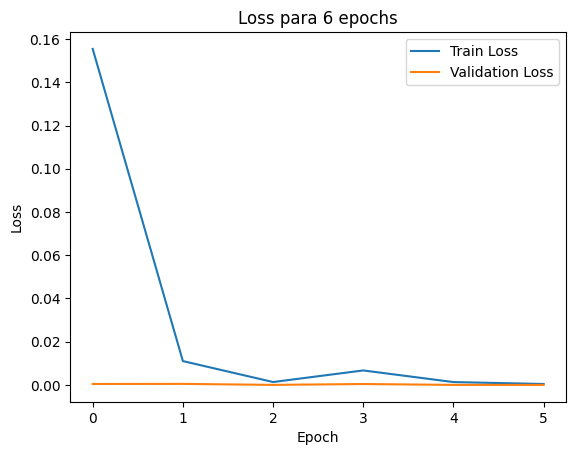

In [ ]:
plt.plot(train_loss_by_epoch, label="Train Loss")
plt.plot(valid_loss_by_epoch, label="Validation Loss")
plt.legend()
plt.title(f"Loss para {len(train_loss_by_epoch)} epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

El gráfico siguiente corresponde al f1 por epoch para train y validation.

Como se puede observar, solamente hay $6$ epochs (comenzando en 0). Esto se explica porque, tanto en *train* como *validate* no hubieron mejoras (en las métricas de validate/evaluación) luego del epoch $0$, por lo que, considernado una tolerancia de early stopping de $5$ pasos, el epoch final fue el número $5$.

La diferencia entre los valores de F1 en *train* y *validation* en los primeros epochs se deben a los mismos motivos que para *loss*/*costo*, es decir, que en *train* se utiliza *drop-out*, y a que el loop de *validate* comienza una vez terminado el loop de *train*, es decir, luego de ajustar pesos de la red.

Se observa que la métrica de $f1$ es igual a $1$ o $100\%$, lo cual podría ser debido a que el modelo está causando *overfitting*. Los motivos podrían ser los mismos que los enumerados para la métrica de *loss*/*coste*.


Text(0, 0.5, 'f1')

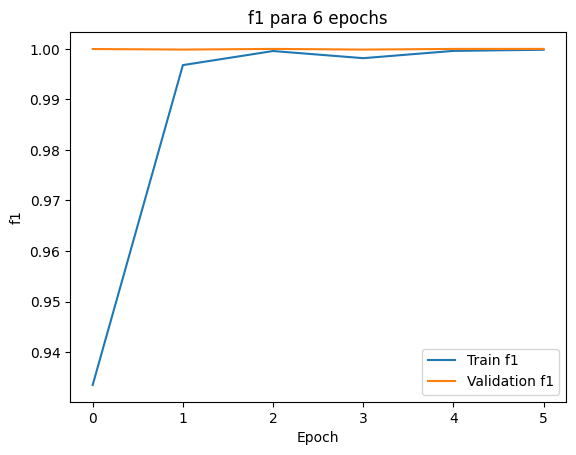

In [ ]:
plt.plot(train_f1_by_epoch, label="Train f1")
plt.plot(valid_f1_by_epoch, label="Validation f1")
plt.legend()
plt.title(f"f1 para {len(valid_f1_by_epoch)} epochs")
plt.xlabel("Epoch")
plt.ylabel("f1")

El gráfico siguiente corresponde al accuracy por epoch para train y validation.

Como se puede observar, solamente hay $6$ epochs (comenzando en 0). Esto se explica porque, tanto en *train* como *validate* no hubieron mejoras (en las métricas de validate/evaluación) luego del epoch $0$, por lo que, considernado una tolerancia de early stopping de $5$ pasos, el epoch final fue el número $5$.

La diferencia entre los valores de accuracy en *train* y *validation* en los primeros epochs se deben a los mismos motivos que para *loss*/*costo* y *f1*, es decir, que en *train* se utiliza *drop-out*, y a que el loop de *validate* comienza una vez terminado el loop de *train*, es decir, luego de ajustar pesos de la red.

Se observa que la métrica de $accuracy$ es igual a $1$ o $100\%$, lo cual podría ser debido a que el modelo está causando *overfitting*. Los motivos podrían ser los mismos que los enumerados para la métrica de *loss*/*coste* y *f1*.


Text(0, 0.5, 'Accuracy')

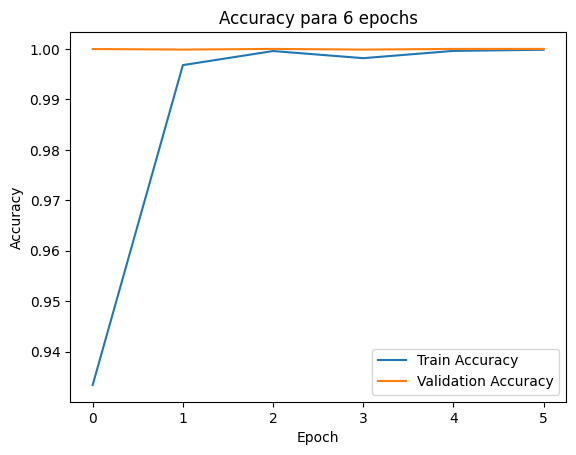

In [ ]:
plt.plot(train_accuracy_by_epoch, label="Train Accuracy")
plt.plot(valid_accuracy_by_epoch, label="Validation Accuracy")
plt.legend()
plt.title(f"Accuracy para {len(valid_accuracy_by_epoch)} epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

In [ ]:
print(np.max(valid_f1_by_epoch))
print(valid_f1_by_epoch[-1])

1.0
1.0


In [ ]:
print(np.max(valid_accuracy_by_epoch))
print(valid_accuracy_by_epoch[-1])

1.0
1.0


### Matriz de confusión

En esta sección se presentan las matrices de confusión *absoluta* y *relativa* (por fila).

En ambos casos se observa que la clasificación es *perfecta*, lo cual indica que el modelo podría estar causando *overfitting*.

Los motivos por los cuales sucede esto pueden ser:

- *DataLeakage*, posiblemente entre los pasos de optimización de hiperparámetros y entrenamiento del modelo.
  - Se descarta que sea en los pasos relacionados a la preparación del dataset (punto `2a)`, ya que el modelo entrenado en `2b)` no presenta estos problemas, y utiliza el mismo dataset como base).
- *Complejidad del modelo*: puede ser que el modelo sea "complejo" en comparación con el dataset inicial.
  - El dataset luego del procesamiento tiene $200752$ registros en *train* y $54817$ registros en *test*, con $11$ columnas en ambos casos (además del Target).
  - El modelo es una red neuronal de dos capas ocultas ($58$ y $29$ respectivamente), que utiliza drop-out y *embeddings* para dos variables del dataset (con dimensiones $382$ para `User_ID` y $127$ para `Product_ID`).

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
Entarget_labels = []
for i in range(4):
  target_val = labelEncoder.inverse_transform([i])
  target_labels.append(target_val[0])

In [ ]:
cm = confusion_matrix(all_targets, all_preds.argmax(dim=1), labels=y_train_emb[TARGET].unique())
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 8434     0     0     0]
 [    0 13279     0     0]
 [    0     0 11594     0]
 [    0     0     0 21510]]


A continuación se presenta la matriz de confusión absoluta. En esta se observa que la clasificación que realiza el modelo es *perfecta*, lo cual podría ser indicio de *overfitting*.

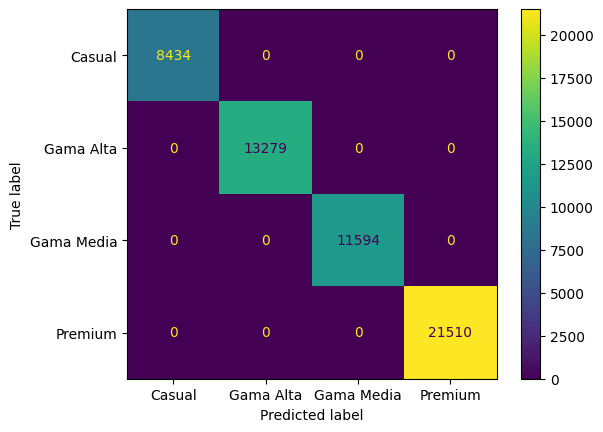

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_labels)
disp.plot()
plt.show()

In [ ]:
cm_normalized_by_row = confusion_matrix(all_targets, all_preds.argmax(dim=1), normalize='true')
print("\nConfusion Matrix Normalized by Row:")
print(cm_normalized_by_row)


Confusion Matrix Normalized by Row:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


A continuación se presenta la matriz de confusión relativa. En esta se observa que la clasificación que realiza el modelo es *perfecta*, lo cual podría ser indicio de *overfitting*.

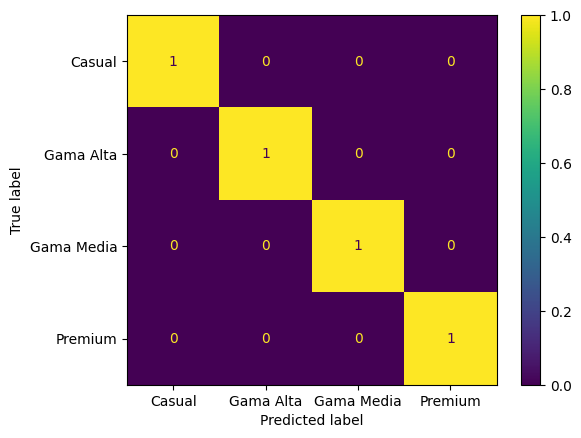

In [ ]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=target_labels)
disp_normalized.plot()
plt.show()

In [ ]:
print(cm_normalized_by_row)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


### Conclusiones

A fin de poder clasificar un dataset de compras según una categoría definida en función de los consumos de usuarios, se modelo una red neuronal que utiliza *embeddings*, los cuales fueron creados para dos columnas o *features* del dataset inicial:

- `User_ID`: presenta un total de $17574$ valores únicos.
- `Product_ID`: presenta un total de $2455$ valores únicos.

***Modelado de embeddings***

Para modelar la capa de embedding de cada una de estas *features* se consideraron las siguientes heurísticas para determinar el tamaño de cada una de estas capas:

- $min(n\_cat//2, 50)$. Fuente: [Medium - Embedding of categorical variables for deep learning](https://medium.com/swlh/embedding-of-categorical-variables-for-deep-learning-model-explained-6aa8a1a04603)
- $min(600, round(1.6 * n\_cat**0.56))$. Fuente: [Size of embedding for categorical variables](https://forums.fast.ai/t/size-of-embedding-for-categorical-variables/42608/2)
- ***n_cat***: cantidad de categorías distintas en una feature/columna.

En función de los valores únicos de cada *feature*, los valores para cada heurística son:

- Heurística 1: $50$ para ambos casos.
- Heurística 2: $381$/$382$ para `User_ID` y $126$/$127$ para `Product_ID`.

A fin de determinar cuál es el valor más óptimo, se realizó una búsqueda de hiperparámetros, la cual arrojó que para la capa de embeddings de `User_ID` el mejor valor es $382$ y para la `Product_ID` es de $127$.

De esta manera, las capas de embedding quedan definidas con estas dimensiones:

- `User_ID`: $17574$ x $382$.
- `Product_ID`: $2455$ x $127$.

La primer dimensión de cada capa se debe a que el objetivo de las mismas es poder enccontrar una representación de un tamaño específico ($382$ para `User_ID` y $127$ para `Product_ID`) para cada ID de cada *feature*.

***Entrenamiento***

Para entrenar este modelo, primero se realizó una optimización de hiperparámetros. Este se realiza sobre el dataset de *train*, haciendo un propio split en train y test, a fin de evitar overfitting.

Una vez determinados los mejores hiperparámetros, se creó una instancia del modelo con estos.

Se ejecutó el loop de entrenamiento, utilizando una función de coste de *CrossEntropyLoss*, *optimizador* de *Adam weighted* y un *scheduler* de *CosineAnnealingWarmRestarts*.

Originalmente se ejecutó el loop con $100$ epochs, pero como se configuró con $early stopping$ con $5$ pasos de *paciencia*, el proceso finalizó en el sexto epoch, ya que no hubo mejoras en las métricas de *loss*, *accuracy* ni *f1* desde el epoch $0$.

Se observó que los resultados de las métricas fueron de $0\%$ para *loss* y $100\%$ para *accuracy* y *f1*, lo cual indica que estamos en una situación de ***overfitting***.

Las causas pueden ser:

- *DataLeakage*, posiblemente entre los pasos de optimización de hiperparámetros y entrenamiento del modelo.
  - Se descarta que sea en los pasos relacionados a la preparación del dataset (punto `2a)`, ya que el modelo entrenado en `2b)` no presenta estos problemas, y utiliza el mismo dataset como base).
- *Complejidad del modelo*: puede ser que el modelo sea "complejo" en comparación con el dataset inicial.
  - El dataset luego del procesamiento tiene $200752$ registros en *train* y $54817$ registros en *test*, con $11$ columnas en ambos casos (además del Target).
  - El modelo es una red neuronal de dos capas ocultas ($58$ y $29$ respectivamente), que utiliza drop-out y *embeddings* para dos variables del dataset (con dimensiones $382$ para `User_ID` y $127$ para `Product_ID`).

Finalmente, se realiza una matriz de confusión absoluta y otra relativa por fila, pero debido a lo mencionado anteriormente, estás indican que la clasificación fue perfecta (es decir, *overfitting*).

***Comparación con modelo sin embeddings***

El modelo ***sin embeddings*** explorado en la sección `2b)` se caracteriza por utilizar una red neuronal de $3$ capas ocultas, sin drop-out, y obviamente sin embeddings. <br/>
En este modelo ***NO*** se utilizan las *features* de `User_ID` y `Product_ID`. <br/>
Éste obtuvo métricas de *accuracy* y *f1* de alrededor del $80\%$, y se caracteriza por clasificar correctamente la mayoría de las veces (más del $90\%$) a las clases `Casual` y `Premium`.<br/>

Respecto al modelo ***con embeddings***, este es una red neuronal de $2$ capas ocultas, con drop-out en cada una de las capas intermedias, y con dos capas de embeddings: una para `User_ID` ($17574$ x $382$) y otra para `Product_ID`($2455$ x $127$). Este modelo tiene *overfitting* (se deduce a partir de que logra un *accuracy* del $100\%$ en los primeros epochs del entrenamiento).

Igualmente, en una situación *sin* overfitting, el modelo ***con embeddings*** va a tener mejor performance que el modelo ***sin embeddings***, ya que los embeddings le permiten capturar relaciones significantes entre categorías, especialmente cuando los vectores de embedding son *similares*.

***Conclusión***

Como conclusión podemos decir que los *embeddings* son herramientas muy útiles para modelar casos en donde algunas *features* presentan cardinalidad muy alta, tal como es el caso de las columnas `User_ID` ($17574$) y `Product_ID` ($2455$).

La dificultad radica en el modelado, ya que existen diversas heurísticas para determinar el tamaño de la *dimensión* de los embeddings. Por ello, es recomendado realizar una optimización de hiperparámetros, para determinar cual de estos valores de cada heurística es el más adecuado.

## 2d) Encontrar usuarios similares

Para buscar usuarios similares a partir del `User Id` se pueden utilizar los embeddings asociados a los usuarios y calcular la similitud coseno entre estos.

Para ello, se crearon las siguientes clases:

- `UserIDSimilarity`: clase para guardar información de usuarios similares, específicamente el user Id y el valor de similitud coseno. Es utilizada en la clase `UserSimilarity`.
- `UserSimilarity`: clase que implementa los métodos necesarios para comparar usuarios.
  - Para instanciarla se necesita un modelo del tipo `ComprasClassifierWithEmbeddings`, y un diccionario que mapea los users ids a los ids utilizados por los embeddings del modelo.
  - método `get_N_similar_users`: a partir de un userId y n, devuelve los *n* usuarios similares.
  - método `format_similarities`: permite imprimir el resultado del método `get_N_similar_users`.

***Procedimiento para obtener usuarios similares***

*Requerimientos*
- Modelo `ComprasClassifierWithEmbeddings` entrenado.
  - El motivo se debe a que, una vez entrenado, los hiperparámetros de la Red han sido actualizados. Esto incluye a la capa de embeddings para `User ID` y `Product ID`.

*Pasos*
1. Obtener un *User ID*.
1. Crear una instancia de la clase `UserSimilarity`.
1. Llamar al método `get_N_similar_users`, pasándole el *User ID* y la cantidad *N* de usuario similares que se desean encontrar.
1. Guardar el resultado del paso anterior en una variable.
1. (Opcional) llamar al método `format_similarities`, pasándole el *User ID* y la variable del paso anterior.

***Fuentes***
- [Understanding Vector Similarity for Machine Learning](https://medium.com/advanced-deep-learning/understanding-vector-similarity-b9c10f7506de)
- [PyTorch - CosineSimilarity](https://docs.pytorch.org/docs/stable/generated/torch.nn.CosineSimilarity.html)

In [ ]:
from typing import List

In [ ]:
class UserIDSimilarity:
  """
  Clase utilizada para representar similaridades entre usuarios.
  Contiene un user_id y un cosine_similarity
  """
  def __init__(self, similar_user_id, cosine_similarity):
    self.similar_user_id = similar_user_id
    self.cosine_similarity = cosine_similarity

In [ ]:
class UserSimilarity:
  """
  Clase que permite obtener similitudes de usuario a partir de los embeddings
  de un modelo entrenado de Deep learning.
  Las similitudes se calcular a partir de la Similitud Coseno
  """
  def __init__(self, model: ComprasClassifierWithEmbeddings, idDict: dict,
               cosDim: int = 1, cosEps: float = 1e-8):
    self.model = model
    self.idDict = idDict
    self.embeddingWeights = model.user_id_embeddings.weight
    self.cosine_similarity_module = nn.CosineSimilarity(dim=cosDim, eps=cosEps)

  def get_N_similar_users(self, userId: int, n: int) -> List[UserIDSimilarity]:
    """
    Devuelve los N usuarios similares a partir de un userId:

    Args:
      userId (int): Usuario cuyas similitudes queremos encontrar.
      n (int): Cantidad de usuarios similares que queremos encontrar.

    Returns:
      List[UserIDSimilarity]: lista con N objetos del tipo UserIDSimilarity

    Raises:
      KeyError: si el userId NO se encuentra en el diccionario.
    """
    similarities = []

    if self.idDict.get(userId, None) is None:
      raise KeyError(f"El id {userId} no se encuentra en el diccionario.")

    # Se obtiene el índice de UserId utilizado para embeddings
    uid = self.idDict[userId]
    # Se obtiene el tensor de embeddings asociado al user id
    uid_emb = model.user_id_embeddings(torch.tensor([uid]))

    # Iteramos sobre todas las embeddings del modelo
    for i in range(self.embeddingWeights.shape[0]):
      if i != uid:
        t = self.model.user_id_embeddings(torch.tensor([i]))
        # Se calcula la similitud coseno
        cos_similarity = self.cosine_similarity_module(t.view(1,-1), uid_emb.view(1,-1)).item()

        # Se obtiene el ID original a partir del indice
        user_id = list(self.idDict.keys())[list(self.idDict.values()).index(i)]

        # Guardamos el ID (del diccionario) y similitud coseno en una clase
        userIDSimilarity = UserIDSimilarity(similar_user_id=i, cosine_similarity=cos_similarity)
        similarities.append(userIDSimilarity)

    # Se ordena de manera descendente por similitud coseno (1=Máx similitud)
    similarities = sorted(similarities, key=lambda s: s.cosine_similarity, reverse=True)

    # N primeros registros similares
    n_similarities = similarities[:n]

    return n_similarities

  def format_similarities(self, userId: int, similarities: List[UserIDSimilarity]):
    """
    Formatea los N usuarios similares a un Usuario dado.

    Args:
      userId (int): Usuario cuyas similitudes queremos mostrar.
      similatiries (List[UserIDSimilarity]): usuarios similares.
    """
    print(f"======== Usuarios con comportamiento de compras similiar al Usuario {userId} ========")
    for user in similarities:
      print(f"\t\t Usuario {user.similar_user_id} - Similitud: {np.round(user.cosine_similarity*100, 2)}%")

In [ ]:
# Instancia de clase que permite obtener usuarios similares
userSimilarities = UserSimilarity(model=model, idDict=userid2id)

A continuación se muestran los Usuarios similares para tres usuarios distintos.

In [ ]:
userId = X_train_final["User_ID"][30]
result = userSimilarities.get_N_similar_users(userId=userId, n=10)
userSimilarities.format_similarities(userId, result)


======== Usuarios con comportamiento de compras similiar al Usuario 1061123 ========
		 Usuario 2751 - Similitud: 20.19%
		 Usuario 291 - Similitud: 19.99%
		 Usuario 13975 - Similitud: 18.8%
		 Usuario 933 - Similitud: 18.4%
		 Usuario 4113 - Similitud: 18.23%
		 Usuario 8067 - Similitud: 17.93%
		 Usuario 9220 - Similitud: 17.89%
		 Usuario 8105 - Similitud: 17.39%
		 Usuario 11221 - Similitud: 17.29%
		 Usuario 2418 - Similitud: 17.23%


In [ ]:
userId = X_train_final["User_ID"][150]
result = userSimilarities.get_N_similar_users(userId=userId, n=10)
userSimilarities.format_similarities(userId, result)


======== Usuarios con comportamiento de compras similiar al Usuario 1065070 ========
		 Usuario 8377 - Similitud: 23.32%
		 Usuario 2962 - Similitud: 18.24%
		 Usuario 16169 - Similitud: 18.12%
		 Usuario 5748 - Similitud: 17.85%
		 Usuario 11289 - Similitud: 17.6%
		 Usuario 14515 - Similitud: 17.57%
		 Usuario 3123 - Similitud: 17.46%
		 Usuario 12089 - Similitud: 17.11%
		 Usuario 8294 - Similitud: 17.04%
		 Usuario 12041 - Similitud: 16.72%


In [ ]:
import random
val = random.randint(0, len(X_train_final["User_ID"]))

userId = X_train_final["User_ID"][val]
result = userSimilarities.get_N_similar_users(userId=userId, n=10)
userSimilarities.format_similarities(userId, result)


======== Usuarios con comportamiento de compras similiar al Usuario 1082807 ========
		 Usuario 3316 - Similitud: 20.27%
		 Usuario 1664 - Similitud: 19.61%
		 Usuario 8697 - Similitud: 18.07%
		 Usuario 3029 - Similitud: 17.88%
		 Usuario 17009 - Similitud: 17.88%
		 Usuario 13453 - Similitud: 17.77%
		 Usuario 16667 - Similitud: 17.58%
		 Usuario 4269 - Similitud: 16.95%
		 Usuario 10923 - Similitud: 16.88%
		 Usuario 5151 - Similitud: 16.77%
